# **System for Detection and Mitigation of Intersectional Biases in Intelligent Systems**


---





## Installation of Ciao Prolog and External Libraries

This section configures the environment for the bias detection and mitigation system, installing Ciao Prolog as the declarative logic engine for selecting mitigation techniques. The process implements:

- **System dependencies**: Installation of compilation and download tools
- **Ciao Prolog**: Download from the official repository, compilation, and local installation
- **Validation**: Verification of the installation using the ciaosh executable
- **Python libraries**: Installation of imbalanced-learn for data balancing techniques

The system avoids unnecessary re-installations through prior checks and optimizes command output to keep the notebook clean.

In [1]:
## Installation of Ciao Prolog and External Libraries

import os

# Verification and cleanup of previous installations to avoid conflicts
# The system checks if ciaosh exists before proceeding with the installation
if not os.path.exists("ciao-master/build/bin/ciaosh"):

    # System package update and installation of essential dependencies
    # Redirection to /dev/null keeps the notebook clean during installation
    !apt-get update > /dev/null 2>&1
    !apt-get install -y build-essential wget curl > /dev/null 2>&1

    print("Starting Ciao Prolog installation...")

    # Download of source code from the official GitHub repository
    !wget -q https://github.com/ciao-lang/ciao/archive/refs/heads/master.zip

    # Silent extraction of the compressed file
    !unzip -q -o master.zip

    # Compilation and local installation of Ciao Prolog
    # Note: This process may take several minutes depending on the system
    !cd ciao-master && ./ciao-boot.sh local-install --with-eng=ciaoengine

    # Installation verification - searches for the ciaosh executable
    !find ciao-master -name "ciaosh" -type f 2>/dev/null | head -5

# Conditional installation of imbalanced-learn for mitigation techniques
try:
    import imblearn
    print("imbalanced-learn is already installed")
except ImportError:
    print("Installing imbalanced-learn...")
    !pip install -q imbalanced-learn
    import imblearn

print("Environment setup completed successfully")

Starting Ciao Prolog installation...
=> builder: building [boot]
   compiling ciaoengine (engine for ciaoc.sta)
   compiling ciao_builder (command) [using ciaoc.sta]
   reusing ciaoengine (engine for ciao_builder)
{WARNING (bundle_configure): Unknown configuration flag `builder:with_eng'}
   Configuration mode... basic
   Verbose builder... no
   Generate documentation... yes
   Generate .asr files during compilation... yes
   Enable parallel builds (experimental)... no
   Installation type... local
   Registration type... user
   Prefix for installation directories... 
   Base for system installation... 
   Installation directory for executables... 
   Installation directory for 'man' pages... 
   Installation directory for 'info' files... 
   Permissions for installed execs/dirs... 775
   Permissions for installed data files... 664
   Custom group for installed files... 
   Path of GNU make command... /usr/bin/gmake
   Path of GNU tar command... /usr/bin/tar
   Update dot shell initi

## Library Imports
This block imports all the necessary dependencies for the bias detection and mitigation system in regression models. Libraries are organized into functional categories for maintainability and clarity.

### Library Categories
- **System and Processes**: Temporary file management, command execution, and time operations
- **Data Processing**: Numerical manipulation, data structures, and tabular analysis
- **Machine Learning**: Regression models, preprocessing, evaluation, and pipelines
- **Visualization**: Charts and visual representations for exploratory analysis
- **Data Balancing**: Bias mitigation techniques for regression problems
- **Utilities**: Typing, abstract classes, and notebook functions

In [2]:
## Library Imports

# --- System and Process Libraries ---
import tempfile       # Creation and management of temporary files and directories
import os             # Interaction with the operating system and path handling
import subprocess     # Execution of system commands and processes
import time           # Operations related to time and delays

# --- Numerical Data Processing ---
import numpy as np    # Efficient numerical operations and multidimensional arrays
import pandas as pd   # Manipulation and analysis of structured data in DataFrames

# --- Typing and Programming Utilities ---
from typing import Dict, Any        # Type annotations for better documentation
from itertools import product       # Generation of Cartesian products for combinations
from abc import ABC, abstractmethod # Definition of abstract classes and interfaces

# --- Notebook Visualization Utilities ---
from IPython.display import clear_output, display  # Presentation enhancement in Jupyter environments

# --- Machine Learning: Datasets and Preprocessing ---
from sklearn.datasets import fetch_openml          # Dataset download from OpenML
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Normalization and encoding
from sklearn.linear_model import LogisticRegression, Ridge       # Linear models
from sklearn.pipeline import Pipeline              # Creation of machine learning pipelines

# --- Data Balancing Techniques ---
from imblearn.over_sampling import RandomOverSampler, SMOTE  # Oversampling algorithms

# --- Ensemble and Evaluation Models ---
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor  # Ensemble models
from sklearn.model_selection import train_test_split         # Data splitting into train/test
from sklearn.metrics import f1_score         # Classification metrics
from sklearn.metrics import mean_squared_error, r2_score     # Regression metrics

# --- Feature Engineering ---
from sklearn.preprocessing import PolynomialFeatures  # Generation of polynomial features

# --- Data Visualization ---
import matplotlib.pyplot as plt  # Creation of charts and static visualizations
import seaborn as sns            # Advanced statistical visualizations

# --- Configuration and Metadata Management ---
from datetime import datetime    # Timestamp recording and date handling
import json                      # JSON data serialization and manipulation

# --- Additional Utilities ---
import traceback                 # For exception diagnosis and debugging

print("All libraries for the regression system have been imported successfully")

All libraries for the regression system have been imported successfully


## Configuration and Data Management
This section defines the central architecture of the system for regression models through three fundamental components:

- **Global Configuration**: Centralizes all parameters, fairness thresholds, and system constants in a single class to ensure consistency and maintainability.

- **Data Loading and Preparation**: Implements specialized loaders for regression datasets (Communities and Crime) with preprocessing, cleaning, and creation of intersectional groups essential for fairness analysis.

- **Model Training**: Provides a standardized trainer to create the production base model (Random Forest Regressor) with data splitting and integrated evaluation.

The modularity allows extensibility for new regression datasets and configurability to adjust fairness criteria.

In [4]:
class Config:
    """
    Centralized configuration of the bias detection and mitigation system for regression.

    Groups all critical parameters, fairness thresholds, and operational constants
    to ensure consistency across all phases of the regression pipeline.

    Attributes:
        SPD_THRESHOLD (float): Threshold for Statistical Parity Difference.
                               Absolute values > 0.1 indicate significant disparity.
        DI_THRESHOLD (float): Threshold for Disparate Impact (80% rule).
                              Values < 0.8 indicate adverse impact.
        EOD_THRESHOLD (float): Threshold for Equal Opportunity Difference.
                               Absolute values > 0.1 indicate disparity in TPR.
        HFI_THRESHOLD (float): Threshold for Harmonic Fairness Intersectional.
                               Values < 0.8 indicate insufficient global fairness.
        PREDICTION_BUFFER_SIZE (int): Buffer size for real-time metrics.
        MONITORING_BATCH_SIZE (int): Metric calculation frequency (every n predictions).
        CIAO_PATH (str): Path to the Ciao Prolog executable for the decision engine.
        UTILITY_WEIGHT_PS (float): Weight of the performance component in final utility.
        UTILITY_WEIGHT_HFI (float): Weight of the fairness component in final utility.
        PS_WEIGHT_R2 (float): Weight of R² in the performance score for regression.
        PS_WEIGHT_RMSE (float): Weight of RMSE in the performance score for regression.
    """

    # Fairness thresholds
    SPD_THRESHOLD = 0.1
    DI_THRESHOLD = 0.8
    EOD_THRESHOLD = 0.1
    HFI_THRESHOLD = 0.8

    # System operational parameters
    PREDICTION_BUFFER_SIZE = 150
    MONITORING_BATCH_SIZE = 150
    CIAO_PATH = "ciao-master/build/bin/ciaosh"

    # Weights for the composite utility function
    UTILITY_WEIGHT_PS = 0.2   # Weight of the performance component (Performance Score)
    UTILITY_WEIGHT_HFI = 0.8  # Weight of the fairness component (Harmonic Fairness Intersectional)

    # Weights for the performance score in regression
    PS_WEIGHT_R2 = 0.5        # Weight of R² in regression performance
    PS_WEIGHT_RMSE = 0.5      # Weight of RMSE in regression performance


class DataLoader:
    """
    Dataset manager for loading, cleaning, and preparing regression data.

    Provides specialized static methods for regression problem datasets
    with standardized preprocessing pipelines and the creation of intersectional
    groups for fairness analysis in continuous predictive models.
    """

    @staticmethod
    def load_communities_crime_data():
        """
        Loads and preprocesses the Communities and Crime dataset from the UCI Repository.

        Returns:
            pandas.DataFrame: Cleaned dataset with continuous target variable and intersectional groups.

        Steps:
            1. Download from the original source with explicit handling of missing values
            2. Cleaning by removing non-predictive columns and those with many missing values
            3. Creation of intersectional groups based on demographic characteristics
            4. Preparation of the continuous target variable (violent crime rate)
        """
        # Communities and Crime dataset URL
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data"

        # Complete dataset column names
        cols = [
            'communityname', 'state', 'county', 'community', 'fold',
            'population', 'householdsize', 'racepctblack', 'racePctWhite', 'racePctAsian',
            'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up',
            'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 'pctWFarmSelf',
            'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc',
            'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap',
            'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade',
            'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu',
            'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce',
            'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
            'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids',
            'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent',
            'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig',
            'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly',
            'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
            'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous',
            'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR',
            'HousVacant', 'PctHousOccup', 'PctHousOwnOcc', 'PctVacantBoarded',
            'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb',
            'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian',
            'RentHighQ', 'MedRent', 'MedRentPctHousInc', 'MedOwnCostPctInc',
            'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 'PctForeignBorn',
            'PctBornSameState', 'PctSameHouse85', 'PctSameCity85', 'PctSameState85',
            'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps',
            'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop',
            'PolicReqPerOffic', 'PolicPerPop', 'RacialMatchCommPol', 'PctPolicWhite',
            'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor',
            'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PolicAveOTWorked',
            'LandArea', 'PopDens', 'PctUsePubTrans', 'PolicCars', 'PolicOperBudg',
            'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn',
            'PolicBudgPerPop', 'ViolentCrimesPerPop'
        ]

        try:
            # Load data handling missing values represented as '?'
            df = pd.read_csv(url, names=cols, na_values='?', skipinitialspace=True)

            # Cleaning: removal of non-predictive columns
            non_predictive_cols = ['communityname', 'state', 'county', 'community', 'fold']
            df_clean = df.drop(non_predictive_cols, axis=1)

            # Remove columns with more than 40% missing values
            missing_threshold = 0.4 * len(df_clean)
            df_clean = df_clean.dropna(axis=1, thresh=missing_threshold)

            # Remove rows with remaining missing values
            df_clean = df_clean.dropna()

            print(f"Dataset loaded: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
            print(f"Target variable 'ViolentCrimesPerPop': range [{df_clean['ViolentCrimesPerPop'].min():.3f}, {df_clean['ViolentCrimesPerPop'].max():.3f}]")

            # Create intersectional groups based on demographic characteristics
            # Income level categorization in terciles
            df_clean['income_level'] = np.digitize(
                df_clean['medIncome'],
                bins=[df_clean['medIncome'].quantile(0.33), df_clean['medIncome'].quantile(0.66)]
            )

            # Determine majority racial group for each community
            race_cols = ['racepctblack', 'racePctWhite', 'racePctHisp']
            df_clean['race_majority'] = df_clean[race_cols].idxmax(axis=1)

            # Map column names to numerical codes
            race_mapping = {'racepctblack': 0, 'racePctWhite': 1, 'racePctHisp': 2}
            df_clean['race_majority_code'] = df_clean['race_majority'].map(race_mapping)

            # Create unique intersectional group identifier
            df_clean['intersectional_group'] = (
                df_clean['race_majority_code'].astype(str) + '_' +
                df_clean['income_level'].astype(str)
            )

            print(f"Intersectional groups created: {df_clean['intersectional_group'].nunique()} unique groups")

            return df_clean

        except Exception as e:
            print(f"Error loading real dataset: {e}")
            print("Generating sample dataset to continue...")
            return DataLoader._create_sample_communities_data()

    @staticmethod
    def _create_sample_communities_data():
        """
        Creates sample data for testing when the real dataset is not available.

        Returns:
            pandas.DataFrame: Synthetic dataset with similar structure to Communities and Crime
        """
        print("Creating sample dataset for testing...")
        np.random.seed(42)
        n_samples = 1000

        # Generate synthetic data with realistic characteristics
        data = {
            'population': np.random.normal(100000, 50000, n_samples),
            'householdsize': np.random.normal(2.5, 0.5, n_samples),
            'racepctblack': np.random.uniform(0, 100, n_samples),
            'racePctWhite': np.random.uniform(0, 100, n_samples),
            'racePctHisp': np.random.uniform(0, 100, n_samples),
            'medIncome': np.random.normal(50000, 20000, n_samples),
            'perCapInc': np.random.normal(25000, 10000, n_samples),
            'PctUnemployed': np.random.uniform(0, 20, n_samples),
            'PctEmploy': np.random.uniform(50, 95, n_samples),
        }

        # Normalize racial percentages to sum to 100%
        race_sum = data['racepctblack'] + data['racePctWhite'] + data['racePctHisp']
        for col in ['racepctblack', 'racePctWhite', 'racePctHisp']:
            data[col] = (data[col] / race_sum) * 100

        # Target variable: violent crime rate (values between 0 and 1)
        data['ViolentCrimesPerPop'] = np.random.uniform(0, 1, n_samples)

        df = pd.DataFrame(data)

        # Create intersectional groups similar to the real dataset
        df['income_level'] = np.digitize(
            df['medIncome'],
            bins=[df['medIncome'].quantile(0.33), df['medIncome'].quantile(0.66)]
        )

        df['race_majority'] = df[['racepctblack', 'racePctWhite', 'racePctHisp']].idxmax(axis=1)
        race_mapping = {'racepctblack': 0, 'racePctWhite': 1, 'racePctHisp': 2}
        df['race_majority_code'] = df['race_majority'].map(race_mapping)
        df['intersectional_group'] = (
            df['race_majority_code'].astype(str) + '_' +
            df['income_level'].astype(str)
        )

        print(f"Sample dataset created: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"Intersectional groups: {df['intersectional_group'].nunique()} unique groups")

        return df

    @staticmethod
    def prepare_features(df, problem_type='regression'):
        """
        Selects and prepares features for the regression model.

        Args:
            df (pandas.DataFrame): Cleaned dataset with all columns
            problem_type (str): Problem type ('regression' or 'classification')

        Returns:
            tuple: (X, Y) where X are the features and Y is the target variable
        """
        # Target variable for the regression problem
        target_col = 'ViolentCrimesPerPop'

        # Columns to exclude (non-predictive, target, and group metadata)
        exclude_cols = [
            target_col, 'income_level', 'race_majority',
            'race_majority_code', 'intersectional_group'
        ]

        # Select only numeric columns for the model
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        feature_cols = [
            col for col in numeric_cols
            if col not in exclude_cols and col != target_col
        ]

        print(f"Preparing {len(feature_cols)} numeric features for {problem_type} model")

        X = df[feature_cols]
        Y = df[target_col]

        return X, Y


class ModelTrainer:
    """
    Standardized trainer for regression models in production.

    Implements the complete training and evaluation pipeline
    for the base model that will be deployed in a production environment
    for regression problems.
    """

    def train_production_model(self, X, y, test_size=0.3, random_state=42, problem_type='regression'):
        """
        Trains a Random Forest model as a base system for production.

        Args:
            X (pandas.DataFrame): Model features.
            y (pandas.Series): Continuous target variable.
            test_size (float): Proportion of the dataset for testing (default: 0.3).
            random_state (int): Seed for reproducibility (default: 42).
            problem_type (str): Problem type ('regression' or 'classification').

        Returns:
            tuple: (model, X_train, X_test, y_train, y_test)
                   - model: Trained Random Forest model
                   - X_train, y_train: Training data
                   - X_test, y_test: Testing data for evaluation

        Note:
            For regression problems, uses RandomForestRegressor with R² and RMSE metrics.
        """
        # Stratified split to preserve the distribution of the target variable
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Configuration and training of the Random Forest model for regression
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        # Evaluation of the base model with regression metrics
        test_r2 = model.score(X_test, y_test)
        y_pred = model.predict(X_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"Regression model trained - R²: {test_r2:.3f}, RMSE: {test_rmse:.3f}")

        return model, X_train, X_test, y_train, y_test

## Bias Detection Module
This module implements the core functionality for real-time monitoring of intersectional biases in the model's predictions. It contains two main classes: BiasMetricsCalculator for calculating fairness metrics and RealTimeBiasMonitor for continuous monitoring and alert detection.

### Intersectional Fairness Metrics

The system calculates four fundamental metrics to evaluate fairness from an intersectional perspective:

- SPD (Statistical Parity Difference): Measures differences in positive prediction rates

- DI (Disparate Impact): Evaluates relative impact between groups using the 80% rule

- EOD (Equal Opportunity Difference): Analyzes disparities in true positive rates

- HFI (Harmonic Fairness Intersectional): Provides an aggregate measure of global fairness

### BiasMetricsCalculator
Calculator specialized in intersectional fairness metrics for regression models.

### Responsibilities
- Calculate statistical fairness metrics specifically adapted for regression problems
- Handle edge cases and extreme values with numerical robustness
- Provide individual measures per group and aggregated global fairness metrics
- Implement specific mathematical formulas for continuous variables

### Implemented Metrics for Regression
- `Statistical Parity Difference (SPD)`: Normalized difference in mean predictions between groups
- `Disparate Impact (DI)`: Ratio of mean predictions between groups with stability limits
- `Equal Opportunity Difference (EOD)`: Difference in mean squared errors between groups
- `Harmonic Fairness Intersectional (HFI)`: Aggregate metric based on variability between groups

In [5]:
class BiasMetricsCalculator:
    """
    Intersectional fairness metrics calculator for regression problems.

    Implements specific versions of fairness metrics adapted to handle
    continuous variables in regression problems, including appropriate
    normalizations and robust handling of edge cases.
    """

    @staticmethod
    def calculate_spd(group_data, other_data):
        """
        Calculates Statistical Parity Difference for regression problems.

        Normalizes the difference in prediction means by the target variable's
        range to make it comparable across different scales.

        Args:
            group_data (DataFrame): Data from the specific intersectional group
            other_data (DataFrame): Data from all other combined groups

        Returns:
            float: Normalized statistical parity difference for regression
                   Values close to 0 indicate fairness, large absolute values indicate bias
        """
        if len(group_data) == 0 or len(other_data) == 0:
            return 0.0

        # Calculate prediction means for each group
        mean_group = group_data['prediction'].mean()
        mean_others = other_data['prediction'].mean()

        # For regression: normalize by the range of the target variable
        target_range = group_data['actual'].max() - group_data['actual'].min()
        if target_range > 0:
            spd = (mean_group - mean_others) / target_range
        else:
            # Fallback: use relative difference if the range is zero
            spd = (mean_group - mean_others) / (mean_others + 1e-8)

        return float(spd)

    @staticmethod
    def calculate_di(group_data, other_data):
        """
        Calculates Disparate Impact for regression problems.

        Calculates the ratio between group prediction means with limits for
        numerical stability and handling of extreme cases.

        Args:
            group_data (DataFrame): Data from the specific intersectional group
            other_data (DataFrame): Data from all other combined groups

        Returns:
            float: Ratio of impacts between groups
                   Values close to 1.0 indicate fairness
                   Values > 1 indicate advantage for the analyzed group
                   Values < 1 indicate disadvantage for the analyzed group
        """
        if len(group_data) == 0 or len(other_data) == 0:
            return 1.0

        mean_group = group_data['prediction'].mean()
        mean_others = other_data['prediction'].mean()

        # Robust handling of division by zero
        if mean_others == 0:
            if mean_group == 0:
                return 1.0  # Both groups with zero mean = perfect fairness
            else:
                # Extreme case: one group has zero mean and the other does not
                return np.inf if mean_group > 0 else 0.0

        di = mean_group / mean_others

        # Apply limits for numerical stability in regression
        # Extreme values may indicate scale problems or severe biases
        if di > 10:
            return 10.0
        elif di < 0.1:
            return 0.1

        return float(di)

    @staticmethod
    def calculate_eod(group_data, other_data):
        """
        Calculates Equal Opportunity Difference for regression problems.

        Measures the difference in predictive quality between groups using
        normalized mean squared errors.

        Args:
            group_data (DataFrame): Data from the specific intersectional group
            other_data (DataFrame): Data from all other combined groups

        Returns:
            float: Difference in accurate prediction opportunities
                   Positive values: worse performance for the analyzed group
                   Negative values: better performance for the analyzed group
                   Zero: fairness in predictive quality
        """
        if len(group_data) == 0 or len(other_data) == 0:
            return 0.0

        # Calculate mean squared errors per group
        mse_group = ((group_data['prediction'] - group_data['actual']) ** 2).mean()
        mse_others = ((other_data['prediction'] - other_data['actual']) ** 2).mean()

        # Normalize by the average error to make it comparable
        mse_avg = (mse_group + mse_others) / 2
        if mse_avg > 0:
            eod = (mse_group - mse_others) / mse_avg
        else:
            eod = 0.0  # Both groups with zero error

        return float(eod)

    @staticmethod
    def calculate_hfi(metrics: Dict[str, Dict[str, Any]]):
        """
        Calculates Harmonic Fairness Intersectional for regression problems.

        Uses coefficients of variation of multiple metrics to measure global
        fairness considering the variability between groups.

        Args:
            metrics (Dict): Dictionary with metrics per intersectional group

        Returns:
            float: Harmonic intersectional fairness metric in [0, 1] scale
                   1.0 = perfect fairness across all groups
                   0.0 = total inequity in at least one dimension
        """
        if not metrics or len(metrics) < 2:
            return 1.0

        # Extract metrics from each group for variability analysis
        spd_values = []
        di_values = []
        eod_values = []
        representations = []

        for group, data in metrics.items():
            spd_values.append(abs(data.get('SPD', 0)))
            di_values.append(data.get('DI', 1.0))
            eod_values.append(abs(data.get('EOD', 0)))
            representations.append(data.get('representation', 0.0))

        fairness_scores = []

        # Component 1: Variability in Statistical Parity Difference
        if spd_values and np.mean(spd_values) > 0:
            cv_spd = np.std(spd_values) / (np.mean(spd_values) + 1e-8)
            fairness_scores.append(1.0 / (1.0 + cv_spd))

        # Component 2: Variability in Disparate Impact (distance to 1.0)
        if di_values:
            di_deviations = [abs(di - 1.0) for di in di_values]
            if np.mean(di_deviations) > 0:
                cv_di = np.std(di_deviations) / (np.mean(di_deviations) + 1e-8)
                fairness_scores.append(1.0 / (1.0 + cv_di))

        # Component 3: Variability in Equal Opportunity Difference
        if eod_values and np.mean(eod_values) > 0:
            cv_eod = np.std(eod_values) / (np.mean(eod_values) + 1e-8)
            fairness_scores.append(1.0 / (1.0 + cv_eod))

        if not fairness_scores:
            return 1.0

        # HFI as the average of the fairness components
        hfi = np.mean(fairness_scores)

        return max(0.0, min(1.0, hfi))

### RealTimeBiasMonitor
Real-time monitoring system for detecting intersectional biases in regression models.

### Responsibilities
- Manage a sliding buffer of recent predictions for continuous analysis
- Periodically calculate fairness metrics over time windows
- Automatically detect and classify different types of statistical biases
- Generate explanatory alerts with context and severity levels

### System Architecture
- **Prediction Buffer**: FIFO storage of predictions for time-window analysis
- **Metrics Calculator**: Engine specialized in calculating fairness metrics for regression
- **Alert Engine**: Multi-criterion detection and bias classification system
- **Severity Analyzer**: Severity classifier based on distance to thresholds

### Main Methods
- `__init__`: Initializes the monitor with model and sensitive attribute configuration
- `ingest_prediction`: Ingests a new prediction into the real-time monitoring buffer
- `calculate_intersectional_metrics`: Calculates metrics for all detected intersectional groups
- `detect_bias_alerts`: Multi-criterion detection system that classifies bias types

In [6]:
class RealTimeBiasMonitor:
    """
    Real-time monitoring system for detection of intersectional biases in regression.

    Simulates a production environment where predictions are ingested continuously,
    calculates fairness metrics over sliding time windows, and generates explanatory
    alerts when statistically significant bias patterns are detected in regression models.
    """

    def __init__(self, model, sensitive_attributes_df):
        """
        Initializes the monitor with the model in production and sensitive data.

        Args:
            model: Regression model deployed in production to be monitored
            sensitive_attributes_df (DataFrame): DataFrame with sensitive attributes for each instance
        """
        self.model = model
        self.sensitive_attributes_df = sensitive_attributes_df
        self.prediction_buffer = []  # FIFO buffer for recent predictions
        self.metrics_calculator = BiasMetricsCalculator()  # Metrics calculator for regression

    def ingest_prediction(self, features, sensitive_attributes, actual_outcome):
        """
        Ingests a new prediction into the real-time monitoring buffer.

        Args:
            features: Input features used for prediction
            sensitive_attributes (dict): Dictionary with sensitive attributes of the instance
            actual_outcome: Actual result (ground truth) for calculating reality-based metrics

        Note:
            Maintains a fixed-size buffer (Config.PREDICTION_BUFFER_SIZE) by removing
            the oldest predictions when capacity is exceeded.
        """
        try:
            # Generate regression model prediction
            prediction = float(self.model.predict(features)[0])

            # Verify that required sensitive attributes are present
            required_attrs = ['race_majority_code', 'income_level']
            for attr in required_attrs:
                if attr not in sensitive_attributes:
                    print(f"Warning: Sensitive attribute '{attr}' not found. Using default value.")
                    sensitive_attributes[attr] = 1  # Default value

            # Create complete prediction record for analysis
            record = {
                'sensitive_attributes': sensitive_attributes,
                'prediction': prediction,
                'prediction_probability': prediction,  # For regression, use prediction as probability
                'actual': float(actual_outcome)
            }

            # Add to buffer and maintain maximum size (FIFO behavior)
            self.prediction_buffer.append(record)
            if len(self.prediction_buffer) > Config.PREDICTION_BUFFER_SIZE:
                self.prediction_buffer.pop(0)  # Remove the oldest prediction

        except Exception as e:
            print(f"Error in prediction ingestion: {e}")

    def calculate_intersectional_metrics(self):
        """
        Calculates fairness metrics for all detected intersectional groups.

        Returns:
            Dict or None: Dictionary with metrics per group, or None if there is insufficient data

        Structure:
            {
                "group_name": {
                    "SPD": float,
                    "DI": float,
                    "EOD": float,
                    "representation": float,
                    "HFI": float
                },
                ...
            }
        """
        # Verify there are enough predictions for statistical analysis
        if len(self.prediction_buffer) < 30:
            print(f"Insufficient buffer for analysis: {len(self.prediction_buffer)} predictions")
            return None

        try:
            # Prepare data for intersectional analysis
            monitor_data = []
            for pred in self.prediction_buffer:
                if pred['actual'] is not None:
                    sens_attrs = pred['sensitive_attributes']
                    # Create unique intersectional group identifier
                    group = f"{sens_attrs['race_majority_code']}_{sens_attrs['income_level']}"

                    monitor_data.append({
                        'intersectional_group': group,
                        'prediction': float(pred['prediction']),
                        'actual': float(pred['actual'])
                    })

            # Verify that there is valid data after filtering
            if not monitor_data:
                print("No data with real values in the buffer for analysis")
                return None

            # Convert to DataFrame for statistical analysis
            monitor_df = pd.DataFrame(monitor_data)
            print(f"Group distribution in buffer: {monitor_df['intersectional_group'].value_counts().to_dict()}")

            results = {}
            total_groups = len(monitor_df['intersectional_group'].unique())

            # Calculate metrics for each unique intersectional group
            for group in monitor_df['intersectional_group'].unique():
                group_data = monitor_df[monitor_df['intersectional_group'] == group]
                other_data = monitor_df[monitor_df['intersectional_group'] != group]

                # Only calculate if there are enough samples in both groups for valid analysis
                if len(group_data) > 3 and len(other_data) > 3:
                    # Calculate specific fairness metrics for regression
                    spd = self.metrics_calculator.calculate_spd(group_data, other_data)
                    di = self.metrics_calculator.calculate_di(group_data, other_data)
                    eod = self.metrics_calculator.calculate_eod(group_data, other_data)

                    # Store results with handling for invalid values
                    results[group] = {
                        'SPD': float(spd) if not np.isnan(spd) else 0.0,
                        'DI': float(di) if not np.isnan(di) and not np.isinf(di) else 1.0,
                        'EOD': float(eod) if not np.isnan(eod) else 0.0,
                        'representation': len(group_data) / len(monitor_df)
                    }

                    print(f"Group {group}: SPD={results[group]['SPD']:.3f}, DI={results[group]['DI']:.3f}, EOD={results[group]['EOD']:.3f}")

            # Calculate and add global HFI to all groups if there are results
            if results:
                hfi_value = self.metrics_calculator.calculate_hfi(results)
                for group in results:
                    results[group]['HFI'] = float(hfi_value)

                print(f"Global HFI calculated: {hfi_value:.3f}")
                print(f"Metrics calculated for {len(results)} of {total_groups} total groups")

            return results

        except Exception as e:
            print(f"Error calculating intersectional metrics: {e}")
            traceback.print_exc()
            return None

    def detect_bias_alerts(self, metrics):
        """
        Detects and classifies biases based on the calculated metrics for regression.

        Implements detection of 4 specific types of statistical biases for
        regression problems, using the thresholds defined in the configuration.

        Args:
            metrics (Dict): Metrics calculated by calculate_intersectional_metrics()

        Returns:
            list: List of detected bias alerts, each with type, group, metric, and severity
        """
        alerts = []

        # Verify that there are valid metrics for analysis
        if metrics is None:
            return alerts

        # Calculate global HFI for selection bias analysis
        hfi_value = self.metrics_calculator.calculate_hfi(metrics)

        print(f"HFI calculated for bias detection: {hfi_value:.3f} (threshold: {Config.HFI_THRESHOLD})")

        # 1. Selection Bias - Insufficient global fairness (low HFI)
        if hfi_value < Config.HFI_THRESHOLD:
            delta = (Config.HFI_THRESHOLD - hfi_value) / Config.HFI_THRESHOLD
            severity = self._calculate_severity(delta, 0.0)  # delta already represents the violation

            alerts.append({
                'group': 'GLOBAL',
                'bias_type': 'Selection Bias',
                'metric': 'HFI',
                'value': hfi_value,
                'threshold': Config.HFI_THRESHOLD,
                'severity': severity
            })

        # 2. Individual group bias analysis
        for group, metric in metrics.items():
            # Representation Bias - Significant difference in mean predictions
            if abs(metric['SPD']) > Config.SPD_THRESHOLD:
                severity = self._calculate_severity(abs(metric['SPD']), Config.SPD_THRESHOLD)
                alerts.append({
                    'group': group,
                    'bias_type': 'Representation Bias',
                    'metric': 'SPD',
                    'value': metric['SPD'],
                    'threshold': Config.SPD_THRESHOLD,
                    'severity': severity
                })

            # Historical Bias - Disparate impact on predictions
            di_value = metric['DI']
            # For regression, verify both directions of bias
            if di_value < Config.DI_THRESHOLD or di_value > (1.0 / Config.DI_THRESHOLD):
                # Calculate maximum deviation from perfect fairness (1.0)
                deviation = max(
                    abs(di_value - 1.0),
                    abs(1.0/di_value - 1.0) if di_value > 0 else 1.0
                )
                severity = self._calculate_severity(deviation, 1.0 - Config.DI_THRESHOLD)

                alerts.append({
                    'group': group,
                    'bias_type': 'Historical Bias',
                    'metric': 'DI',
                    'value': di_value,
                    'threshold': Config.DI_THRESHOLD,
                    'severity': severity
                })

            # Measurement Bias - Disparity in predictive quality
            if metric.get('EOD') is not None and abs(metric['EOD']) > Config.EOD_THRESHOLD:
                severity = self._calculate_severity(abs(metric['EOD']), Config.EOD_THRESHOLD)
                alerts.append({
                    'group': group,
                    'bias_type': 'Measurement Bias',
                    'metric': 'EOD',
                    'value': metric['EOD'],
                    'threshold': Config.EOD_THRESHOLD,
                    'severity': severity
                })

            # Exclusion Bias - Group with insufficient representation
            if metric.get('representation', 0) < 0.03:  # Less than 3% representation
                severity = self._calculate_severity(0.03 - metric['representation'], 0.03)
                alerts.append({
                    'group': group,
                    'bias_type': 'Exclusion Bias',
                    'metric': 'Representation',
                    'value': metric['representation'],
                    'threshold': 0.05,  # Desirable representation threshold
                    'severity': severity
                })

        print(f"Total bias alerts generated: {len(alerts)}")
        return alerts

    def _calculate_severity(self, deviation, threshold):
        """
        Calculates severity level based on the deviation from the threshold.

        Args:
            deviation (float): Magnitude of deviation from the threshold
            threshold (float): Reference threshold value

        Returns:
            str: "LOW", "MEDIUM", or "HIGH" based on the magnitude of the violation
        """
        if threshold == 0:
            return "MEDIUM"

        ratio = deviation / threshold
        if ratio > 2.0:
            return "HIGH"
        elif ratio > 1.0:
            return "MEDIUM"
        else:
            return "LOW"

## Mitigation Technique Decision Module
This module implements the decision-making system to automatically select the most appropriate mitigation techniques based on detected biases. It uses Ciao Prolog as a declarative logic engine that emulates human expert reasoning, combined with a Python interface for integration with the rest of the system.

### Decision System Architecture
The module follows a hybrid approach where:

- Ciao Prolog handles complex selection rules based on bias types, severity, and metrics
- Python provides the integration interface and fallback handling
- Decisions are prioritized based on criticality and the type of detected bias

### CiaoPrologEngine
Expert decision engine for bias mitigation using Ciao Prolog as a rule-based system.

### Responsibilities
- Configure and manage the Prolog module with expert mitigation rules
- Execute Prolog queries securely with robust error and timeout handling
- Process lists of bias alerts and return optimized mitigation techniques
- Provide fallback mechanisms when the Prolog engine is unavailable

### System Architecture
- **Rule Engine**: Prolog knowledge base with techniques classified by phase and severity
- **Query Handler**: Secure execution with timeouts and response processing
- **Fallback System**: Alternative mechanisms when Ciao Prolog is unavailable
- **Diversity Validator**: Ensures balanced coverage across processing phases

### Main Methods
- `__init__`: Initializes the engine with Ciao Prolog availability verification
- `setup_prolog_module`: Configures the Prolog module with expert mitigation rules
- `execute_query_clean`: Executes Prolog queries with robust error handling
- `process_mitigation_alerts`: Processes alerts and returns recommended mitigation techniques

In [8]:
class CiaoPrologEngine:
    """
    Mitigation decision engine using Ciao Prolog.

    Expert rule-based system that uses Ciao Prolog to select optimal bias mitigation
    techniques based on the type and severity of alerts detected in regression models.
    """

    def __init__(self):
        """Initializes the Prolog engine with availability verification."""
        self.ciao_path = Config.CIAO_PATH
        self.setup_prolog_module()  # Configure Prolog module upon initialization
        self._verify_ciao_availability()  # Verify that Ciao Prolog is available

    def _verify_ciao_availability(self):
        """
        Verifies that Ciao Prolog is available on the system.

        Searches multiple alternative paths and activates fallback mode if the
        Ciao Prolog executable is not found.
        """
        if not os.path.exists(self.ciao_path):
            # Attempt to find alternative executable in common paths
            alternative_paths = [
                "ciao-master/build/bin/ciaosh",
                "./ciao-master/build/bin/ciaosh",
                "ciaosh",
                "/usr/local/bin/ciaosh",
                "/usr/bin/ciaosh"
            ]
            for path in alternative_paths:
                if os.path.exists(path):
                    self.ciao_path = path
                    print(f"Ciao Prolog found at: {path}")
                    return

            print("Ciao Prolog unavailable - fallback mode activated")
            self.ciao_path = None
        else:
            print(f"Ciao Prolog verified at: {self.ciao_path}")

    def setup_prolog_module(self):
        """
        Configures the Prolog module with decision rules for mitigation.

        Defines the expert knowledge base containing:
        - Classification of techniques by processing phase
        - Alert -> technique mapping rules based on type and severity
        - Optimization logic for balanced pipeline selection
        """
        prolog_code = r"""
:- module(mitigation_selector, [process_alerts/2, select_technique/2]).
:- use_module(library(lists)).
:- use_module(library(aggregates)).

% ============================================================
% 1. KNOWLEDGE BASE
% ============================================================

% Definition of phases (Pipeline)
technique_phase(resampling,                     pre).
technique_phase(reweighting,                    pre).
technique_phase(feature_augmentation,           pre).
technique_phase(nsga_ii,                        in).
technique_phase(heuristic_threshold_adjustment, post).

technique_strength(resampling,                     11).
technique_strength(reweighting,                    5).
technique_strength(nsga_ii,                        10).
technique_strength(feature_augmentation,           5).
technique_strength(heuristic_threshold_adjustment, 5).

% Severity multipliers
severity_weight(critical, 4).
severity_weight(high,     3).
severity_weight(medium,   2).
severity_weight(low,      1).

% ============================================================
% 2. MAPPING RULES (Alert -> Technique)
% ============================================================

% -- Representation Bias --
select_technique(alert(representation, _, _, Severity), resampling) :-
    (Severity = critical ; Severity = high).
select_technique(alert(representation, _, _, Severity), reweighting) :-
    (Severity = medium ; Severity = low).

% -- Selection Bias --
select_technique(alert(selection, _, _, _), resampling).

% -- Measurement Bias --
select_technique(alert(measurement, _, _, high), nsga_ii).
select_technique(alert(measurement, _, _, critical), nsga_ii).
select_technique(alert(measurement, _, _, medium), feature_augmentation).
select_technique(alert(measurement, _, _, low), feature_augmentation).

% -- Historical Bias --
select_technique(alert(historical, _, _, critical), feature_augmentation).
select_technique(alert(historical, _, _, high), feature_augmentation).
select_technique(alert(historical, _, _, _), heuristic_threshold_adjustment).

% -- Feature Exclusion Bias --
select_technique(alert(feature_exclusion, _, _, _), feature_augmentation).

% -- General fallback --
select_technique(alert(_, _, _, critical), resampling).

% ============================================================
% 3. MAIN LOGIC
% ============================================================

process_alerts(Alerts, FinalTechniques) :-
    % 1. Find candidates with their calculated weights
    findall(candidate(Phase, Tech, Weight),
            (member(Alert, Alerts),
             calculate_candidate_weight(Alert, Phase, Tech, Weight)),
            Candidates),

    % 2. Optimize pipeline (choose best per phase)
    optimize_pipeline(Candidates, SelectedLists),

    % 3. Flatten the list of lists into a simple list
    flatten_techniques(SelectedLists, FinalTechniques).

% Calculate weight: Technique strength * Alert severity
calculate_candidate_weight(Alert, Phase, Tech, TotalWeight) :-
    Alert = alert(_, _, _, Severity),
    select_technique(Alert, Tech),
    technique_phase(Tech, Phase),
    technique_strength(Tech, BaseStr),
    severity_weight(Severity, SevMult),
    TotalWeight is BaseStr * SevMult.

% ============================================================
% 4. PIPELINE OPTIMIZATION
% ============================================================

optimize_pipeline(Candidates, Pipeline) :-
    select_best_in_phase(Candidates, pre, PreTech),
    select_best_in_phase(Candidates, in, InTech),
    select_best_in_phase(Candidates, post, PostTech),
    % Build list with results (can be empty)
    Pipeline = [PreTech, InTech, PostTech].

% Select the best candidate for a phase
select_best_in_phase(Candidates, TargetPhase, [BestTech]) :-
    % Filter candidates of this phase
    findall(w(W, T),
            member(candidate(TargetPhase, T, W), Candidates),
            PhaseCandidates),
    PhaseCandidates \= [], % Ensure there are candidates
    % Sort to find the maximum weight
    % sort/2 sorts ascending, reverse puts it descending
    sort(PhaseCandidates, Sorted),
    reverse(Sorted, [w(_, BestTech)|_]), !.

% If no candidates, return empty list
select_best_in_phase(_, _, []).

% ============================================================
% 5. UTILITIES
% ============================================================

% Flatten list of lists and remove duplicates (manual to avoid dependencies)
flatten_techniques([], []).
flatten_techniques([[]|T], Rest) :- !, flatten_techniques(T, Rest).
flatten_techniques([[X]|T], [X|Rest]) :- !, flatten_techniques(T, Rest).
flatten_techniques([H|T], [H|Rest]) :- atom(H), !, flatten_techniques(T, Rest).
"""
        # Write Prolog code to file for execution
        try:
            with open('mitigation_selector.pl', 'w') as f:
                f.write(prolog_code)
            # Verify that the file was created correctly
            if os.path.exists('mitigation_selector.pl'):
                print("Prolog file verified")
            else:
                print("Error: Prolog file was not created")

        except Exception as e:
            print(f"Error creating Prolog file: {e}")

    def execute_query_clean(self, query):
        """
        Executes Prolog query securely with robust error handling.

        Args:
            query (str): Prolog query to execute

        Returns:
            tuple: (success, raw_output, response)
                   - success: Boolean indicating if execution was successful
                   - raw_output: Raw output of the Prolog process
                   - response: Extracted techniques or processed response
        """
        # Verify Ciao Prolog availability
        if self.ciao_path is None:
            print("Ciao Prolog unavailable, using fallback")
            return False, "Ciao Prolog not available", None

        # Create temporary script for execution
        with tempfile.NamedTemporaryFile(mode='w', suffix='.pl', delete=False) as f:
            script_path = f.name
            f.write("use_module(mitigation_selector).\n")  # Load module
            f.write(f"{query}.\n")  # Execute query
            f.write("halt.\n")  # End execution

        print(f"Executing Prolog query: {query}")

        try:
            # Execute query with timeout to prevent blocking
            cmd = f"cat {script_path} | {self.ciao_path} -q 2>/dev/null"
            result = subprocess.run(
                cmd, shell=True, capture_output=True, text=True, timeout=8
            )

            # Process Prolog process output
            output = result.stdout.strip()
            success = result.returncode == 0

            print(f"Prolog output: '{output}'")

            if success and output:
                # Search for techniques in output using multiple methods
                techniques = self._extract_techniques_from_output(output)
                if techniques:
                    return True, output, techniques
                else:
                    # Attempt alternative extraction method
                    if "UniqueTechniques =" in output:
                        response = output.split("UniqueTechniques = ")[-1].replace(" ;", "").replace(".", "").strip()
                        return True, output, response

            return False, output, None

        except subprocess.TimeoutExpired:
            print("Timeout in Prolog query")
            return False, "Query timed out", None
        except Exception as e:
            print(f"Error executing Prolog: {e}")
            return False, str(e), None
        finally:
            # Cleanup: remove temporary file
            try:
                os.remove(script_path)
            except:
                pass

    def _extract_techniques_from_output(self, output):
        """
        Extraction of techniques from Prolog output using direct search.

        Args:
            output (str): Textual output of the Prolog engine

        Returns:
            list or None: List of found techniques or None if not detected
        """
        techniques = []

        # Direct search for technique names in output
        if 'reweighting' in output:
            techniques.append('reweighting')
        if 'resampling' in output:
            techniques.append('resampling')
        if 'nsga_ii' in output:
            techniques.append('nsga_ii')
        if 'heuristic_threshold_adjustment' in output:
            techniques.append('heuristic_threshold_adjustment')
        if 'feature_augmentation' in output:
            techniques.append('feature_augmentation')

        return techniques if techniques else None

    def process_mitigation_alerts(self, prolog_alerts):
        """
        Process alerts and return recommended mitigation techniques.

        Args:
            prolog_alerts (list): List of alerts in Prolog format
                                 Ej: ['alert(representation, group1, spd, high)']

        Returns:
            list: List of recommended and validated mitigation techniques
        """
        # Build Prolog query
        print(f"Processing {len(prolog_alerts)} alerts with Ciao Prolog")

        # Execute query to Prolog rule engine
        query = f"process_alerts([{', '.join(prolog_alerts)}], UniqueTechniques)"
        success, raw_output, response = self.execute_query_clean(query)

        if success and response:
            try:
                if isinstance(response, list):
                    return response
                else:
                    # Process string response in Prolog list format
                    techniques = [t.strip() for t in response.strip('[]').split(',') if t.strip()]
                    return self._validate_technique_diversity(techniques)
            except Exception as e:
                print(f"Error processing response: {e}")
                return []

        print("Ciao Prolog engine failed, using fallback")
        return []  # Empty list if no techniques selected

    def _validate_technique_diversity(self, techniques):
        """
        Validation and filtering of techniques to ensure diversity in phases.

        Args:
            techniques (list): Raw list of recommended techniques

        Returns:
            list: Filtered list with a maximum of one technique per processing phase
        """
        if not techniques:
            return techniques

        print(f"Validating technique diversity")

        # Sort by mitigation phase (pre, in, post-processing)
        phase_order = {
            'resampling': 1,    # Pre-processing
            'reweighting': 1,   # Pre-processing
            'nsga_ii': 2,       # In-processing
            'feature_augmentation': 2,  # In-processing
            'heuristic_threshold_adjustment': 3   # Post-processing
        }

        # Filter: maximum 1 technique per phase to avoid redundancy
        techniques_by_phase = {}
        for tech in techniques:
            phase = phase_order.get(tech, 1)
            if phase not in techniques_by_phase:
                techniques_by_phase[phase] = tech

        filtered_techniques = list(techniques_by_phase.values())
        print(f"Validated techniques: {filtered_techniques}")
        return filtered_techniques

### MitigationSelector
Python interface for the mitigation decision engine that acts as a bridge between the Python system and the Prolog engine.

### Responsibilities
- Convert alerts from Python format to Prolog format for processing
- Select mitigation techniques based on alert analysis
- Handle robust fallback logic when the Prolog engine is unavailable
- Log decision history for monitoring and analysis

### Key Features
- **Alert Translation**: Bidirectional conversion between Python and Prolog formats
- **Intelligent Selection**: Integration with Prolog expert rules engine
- **Fallback System**: Contingency logic when Prolog does not respond
- **Audit**: Complete log of mitigation decision history

### Main Methods
- `__init__`: Initializes the selector with the Prolog engine and backup systems
- `python_to_prolog_alerts`: Converts Python alerts to executable Prolog format
- `select_mitigation`: Selects mitigation techniques based on alert analysis
- `_improved_fallback_selection`: Fallback logic when Prolog is unavailable

In [10]:
class MitigationSelector:
    """
    Python interface for the mitigation decision engine.

    Acts as a translation bridge between the Python monitoring system
    and the Prolog expert rule engine, also providing robust fallback
    mechanisms and decision logging for regression problems.
    """

    def __init__(self):
        """
        Initializes the selector with the engine and backup systems.

        Configures:
        - Ciao Prolog engine for decisions based on expert rules
        - Fallback counter to monitor system reliability
        - Decision history for audit and post-mortem analysis
        """
        self.ciao_engine = CiaoPrologEngine()  # Prolog decision engine
        self.fallback_count = 0  # Counter for fallback mode activations
        self.decision_history = []  # Full decision history for audit and analysis

    def python_to_prolog_alerts(self, alerts):
        """
        Converts Python alerts to executable Prolog format.

        Args:
            alerts (list): List of alerts in Python/dict format
                         [{'bias_type': str, 'severity': str, 'metric': str, 'group': str}]

        Returns:
            list: List of Prolog terms in executable format
                 Ej: ["alert(representation, 'group1', [spd], high)"]
        """
        prolog_alerts = []

        # Mappings for robust bias type conversion
        bias_type_map = {
            'Representation Bias': 'representation',
            'Historical Bias': 'historical',
            'Measurement Bias': 'measurement',
            'Selection Bias': 'selection',
            'Feature Exclusion Bias': 'feature_exclusion'
        }

        # Severity level mapping
        severity_map = {
            'LOW': 'low', 'MEDIUM': 'medium', 'HIGH': 'high', 'CRITICAL': 'critical'
        }

        # Metric name mapping
        metric_map = {
            'Statistical Parity': 'spd',
            'Disparate Impact': 'di',
            'Equal Opportunity': 'eod',
            'Historical Fairness Index': 'hfi'
        }

        for alert in alerts:
            try:
                # Bias type normalization with improved mapping
                original_bias_type = alert['bias_type']
                bt = bias_type_map.get(original_bias_type,
                                    original_bias_type.split()[0].lower().replace('_', ''))

                # Severity normalization with standard mapping
                severity = severity_map.get(alert['severity'],
                                          alert['severity'].lower())

                # Metric normalization with comprehensive mapping
                original_metric = alert['metric']
                metric = metric_map.get(original_metric,
                                      original_metric.lower().split()[-1])

                # Group name cleaning for security in Prolog
                group = alert['group'].replace("'", "").replace('"', '')[:50]

                # Build executable Prolog term
                prolog_term = f"alert({bt}, '{group}', [{metric}], {severity})"
                prolog_alerts.append(prolog_term)

            except Exception as e:
                print(f"Error converting alert: {e}")
                # Fallback to simple method for maximum compatibility
                bt = alert['bias_type'].split()[0].lower().replace('_', '')
                severity = alert['severity'].lower()
                metric = alert['metric'].lower().split()[-1]
                prolog_term = f"alert({bt}, '{alert['group']}', [{metric}], {severity})"
                prolog_alerts.append(prolog_term)

        print(f"Converted {len(prolog_alerts)} alerts to Prolog format")
        return prolog_alerts

    def select_mitigation(self, alerts):
        """
        Selects mitigation techniques based on detected alerts.

        Args:
            alerts (list): List of alerts detected by the real-time monitor

        Returns:
            list: List of recommended mitigation techniques
                 Ej: ['resampling', 'feature_augmentation']
        """
        # Case with no alerts: use default technique
        if not alerts:
            return ['feature_augmentation']

        print(f"Selecting mitigation for {len(alerts)} alerts...")

        # Convert Python alerts to executable Prolog format
        prolog_alerts = self.python_to_prolog_alerts(alerts)

        # Query Prolog engine for decision based on expert rules
        techniques = self.ciao_engine.process_mitigation_alerts(prolog_alerts)

        # Fallback: if Prolog does not return techniques (engine unavailable or error)
        if not techniques:
            self.fallback_count += 1
            print(f"Using fallback (count: {self.fallback_count})")
            techniques = self._improved_fallback_selection(alerts)
        else:
            print("Prolog successfully selected techniques")

        # Log decision to history for audit
        self._record_decision(alerts, techniques)

        print(f"Final techniques selected: {techniques}")
        return techniques

    def _improved_fallback_selection(self, alerts):
        """
        Improved fallback for technique selection when Prolog is unavailable.

        Implements heuristic logic based on bias type and severity
        as a backup to the Prolog expert system.

        Args:
            alerts (list): List of alerts in Python format

        Returns:
            list: List of mitigation techniques selected by fallback
        """
        techniques_set = set()

        # Heuristic logic based on bias type and severity
        for alert in alerts:
            bias_type = alert['bias_type']
            severity = alert['severity']

            # Direct type->technique mapping based on expert knowledge
            if 'Representation' in bias_type:
                techniques_set.add('resampling' if severity == 'HIGH' else 'reweighting')
            elif 'Selection' in bias_type:
                techniques_set.add('resampling')
            elif 'Historical' in bias_type:
                techniques_set.add('heuristic_threshold_adjustment')
            elif 'Measurement' in bias_type:
                techniques_set.add('nsga_ii')
            elif 'Feature' in bias_type:
                techniques_set.add('feature_augmentation')
            else:
                # Generic fallback for unmapped bias types
                techniques_set.add('reweighting')

        # Ensure at least one technique is selected
        techniques = list(techniques_set) if techniques_set else ['reweighting', 'feature_augmentation']

        # Apply diversity validation to avoid redundancy in phases
        return self.ciao_engine._validate_technique_diversity(techniques)

    def _record_decision(self, alerts, techniques):
        """
        Log decision for monitoring and audit.

        Args:
            alerts (list): Alerts that motivated the decision
            techniques (list): Selected mitigation techniques
        """
        decision = {
            'timestamp': pd.Timestamp.now() if 'pd' in globals() else 'N/A',
            'alerts_count': len(alerts),
            'techniques': techniques,
            'used_fallback': self.fallback_count > 0
        }
        self.decision_history.append(decision)
        print(f"Decision logged in history: {decision}")

## Mitigation Execution Module
This module implements the practical execution of all bias mitigation techniques available in the system. Each technique addresses specific types of biases through different strategies: pre-processing, in-processing, post-processing, and feature augmentation.

### Implemented Mitigation Techniques
The system includes five main techniques that cover the full spectrum of approaches to mitigate intersectional biases:

- **Reweighting:** Weight adjustment for underrepresented groups

- **Resampling:** Balancing via oversampling of minority groups

- **Heuristic Threshold Adjustment:** Adaptive threshold adjustment by group

- **NSGA-II:** Multi-objective retraining (simplified)

- **Feature Augmentation:** Feature expansion via polynomial interactions

### BaseMitigationTechnique  
Abstract base class for all bias mitigation techniques in regression. Defines the common interface and provides shared functionality for specific implementations.

### Responsibilities
- Define the common interface that all mitigation techniques for regression must implement
- Provide auxiliary methods for intersectional analysis and data handling
- Manage access to sensitive data and fairness metrics calculation
- Establish the base structure for the mitigation pipeline in regression problems

### Main Methods
- `__init__`: Initializes the base technique with data, model, and metrics calculator
- `apply`: Abstract method to apply the specific mitigation technique
- `_get_intersectional_groups`: Helper method to obtain intersectional groups

In [11]:
class BaseMitigationTechnique(ABC):
    """
    Abstract base class for all bias mitigation techniques in regression.

    Provides the common structure, auxiliary methods, and data management
    for all specific implementations of mitigation techniques in regression
    problems. Subclasses must implement the apply() method with the specific
    logic of each technique.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator):
        """
        Initializes the base technique with data, model, and necessary dependencies.

        Args:
            model: Regression model to be mitigated
            X_train: Training features
            y_train: Training continuous target variable
            X_test: Test features
            y_test: Test continuous target variable
            df_sensitive: DataFrame with sensitive attributes and intersectional groups
            metrics_calculator: Instance for calculating fairness metrics in regression
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.df_sensitive = df_sensitive
        self.metrics_calculator = metrics_calculator

    @abstractmethod
    def apply(self):
        """
        Abstract method to apply the specific mitigation technique.

        Returns:
            tuple: (predictions, mitigated_model) where:
                  - predictions: Predictions from the mitigated model (continuous values)
                  - mitigated_model: Model trained with the technique applied

        Note:
            All subclasses must implement this method with the specific
            logic of the mitigation technique for regression problems.
        """
        pass

    def _get_intersectional_groups(self, data=None):
        """
        Helper method to obtain intersectional groups from the dataset.

        Args:
            data (DataFrame, optional): Alternative DataFrame to extract groups.
                                       If None, uses self.df_sensitive.

        Returns:
            Series: Pandas series with the intersectional group identifiers
        """
        if data is None:
            data = self.df_sensitive
        return data['intersectional_group']

### Reweighting
Pre-processing technique that applies weight rescaling to address imbalances in intersectional groups in regression problems.

### Strategy
- Calculates the distribution of intersectional groups in the training data
- Assigns weights inversely proportional to the frequency of each group
- Normalizes weights to maintain the stability of the training process
- Trains a new model with adjusted weights to balance the influence of groups

### Main Methods
- `apply`: Applies reweighting and trains a new model with the adjusted weights

In [12]:
class Reweighting(BaseMitigationTechnique):
    """
    Mitigation technique that applies smoothed reweighting for regression.
    """
    def apply(self):
        print("Applying Reweighting (Micro-adjustment for Regression)...")
        sensitive_train = self.df_sensitive.loc[self.X_train.index]
        group_col = self._get_intersectional_groups(sensitive_train)
        group_counts = group_col.value_counts()
        total_samples = len(group_col)

        # Strong weight attenuation (using fourth root) to avoid distorting R2
        weights = group_col.map(lambda g: np.power(total_samples / (len(group_counts) * group_counts[g]), 0.25))
        weights = weights / weights.mean()

        mitigated_model = RandomForestRegressor(
            n_estimators=100,
            random_state=np.random.randint(0, 10000), # Dynamic seed to explore options
            min_samples_leaf=2 # Helps generalize better by avoiding overfitting to weights
        )
        mitigated_model.fit(self.X_train, self.y_train, sample_weight=weights)

        y_pred = mitigated_model.predict(self.X_test)
        return y_pred, mitigated_model

### Resampling
Pre-processing technique that applies intelligent oversampling to balance the distribution of intersectional groups in regression problems using the "binned oversampling" strategy.

### Strategy
- **Binned Oversampling**: Divides the continuous target variable into bins using quantiles
- **Intelligent Balancing**: Applies RandomOverSampler to the resulting categorical bins
- **Continuous Reconstruction**: Regenerates continuous values while preserving the original distribution
- **Variability Management**: Incorporates controlled noise to maintain data diversity

### Main Methods
- `apply`: Main entry point that delegates to the proven binned oversampling method
- `_apply_binned_oversampling`: Core implementation with adaptive strategies for continuous value regeneration

### Processing Flow
1. **Discretization**: Conversion of continuous variable to bins using quantiles
2. **Balancing**: Application of oversampling to the discrete representation
3. **Reconstruction**: Intelligent regeneration of continuous values by bin
4. **Training**: Modeling with Random Forest optimized for balanced data

In [13]:
class Resampling(BaseMitigationTechnique):
    """
    Resampling technique specialized for regression using binned oversampling.

    Implements an innovative approach that combines intelligent discretization of the
    continuous target variable with oversampling techniques, followed by adaptive
    reconstruction of continuous values to maintain original statistical properties
    while balancing group distribution.
    """

    def apply(self):
        """
        Applies specialized resampling for regression problems.

        Returns:
            tuple: (y_pred, mitigated_model) where:
                  - y_pred: Predictions from the model trained with balanced data
                  - mitigated_model: Random Forest model trained with resampled dataset

        Note:
            Delegates specific implementation to the _apply_binned_oversampling()
            method which has been previously validated and tested in a regression context.
        """
        print("Applying resampling for REGRESSION...")

        # Use directly the method we know works
        return self._apply_binned_oversampling()

    def _apply_binned_oversampling(self):
        """
        Implementation of binned oversampling with intelligent reconstruction for regression.

        Multi-phase strategy:
        1. Adaptive discretization of the continuous target variable into bins
        2. Application of RandomOverSampler to balance bin distribution
        3. Intelligent reconstruction of continuous values preserving statistics
        4. Training of model with balanced and reconstructed dataset

        Returns:
            tuple: (y_pred, mitigated_model) with predictions and mitigated model
        """
        # Phase 1: Adaptive discretization based on data distribution
        # Calculate optimal number of bins balancing granularity and sample size
        n_bins = min(8, len(self.y_train) // 30)  # Adjust number of bins
        if n_bins < 3:
            n_bins = 3  # Minimum bins to maintain distribution structure

        print(f"Creating {n_bins} bins for resampling...")

        # Use quantiles to create bins of similar size preserving distribution
        quantiles = np.linspace(0, 1, n_bins + 1)
        bin_edges = np.quantile(self.y_train, quantiles)
        bin_edges[0] = -np.inf  # Ensure all points are included
        bin_edges[-1] = np.inf

        # Discretize continuous target variable into categorical bins
        y_binned = pd.cut(self.y_train, bins=bin_edges, labels=False, include_lowest=True)

        # Verify bin distribution for diagnostics
        bin_counts = pd.Series(y_binned).value_counts().sort_index()
        print(f"Original distribution by bins: {dict(bin_counts)}")

        # Phase 2: Application of oversampling to discrete representation
        sampler = RandomOverSampler(random_state=42)
        X_res, y_binned_res = sampler.fit_resample(self.X_train, y_binned)

        # Verify new balanced distribution
        new_bin_counts = pd.Series(y_binned_res).value_counts().sort_index()
        print(f"Distribution after resampling: {dict(new_bin_counts)}")

        # Phase 3: Intelligent reconstruction of continuous values
        y_res = np.zeros(len(X_res))

        for bin_idx in range(n_bins):
            bin_mask = (y_binned_res == bin_idx)
            original_bin_mask = (y_binned == bin_idx)

            if original_bin_mask.any() and bin_mask.any():
                # Original values of this bin for statistical reference
                original_values = self.y_train[original_bin_mask].values
                n_samples_needed = bin_mask.sum()

                if len(original_values) > 0:
                    # Strategy 1: For bins with enough data, sample with replacement
                    if len(original_values) >= 5:
                        sampled_indices = np.random.choice(
                            len(original_values),
                            size=n_samples_needed,
                            replace=True
                        )
                        base_values = original_values[sampled_indices]
                    else:
                        # Strategy 2: For small bins, use the mean with variation
                        base_values = np.full(n_samples_needed, np.mean(original_values))

                    # Add small perturbation for controlled variability
                    std_original = np.std(original_values)
                    if std_original > 0:
                        noise_scale = 0.1 * std_original  # Noise proportional to original variability
                    else:
                        noise_scale = 0.01 * np.std(self.y_train)  # Noise based on global variability

                    noise = np.random.normal(0, noise_scale, n_samples_needed)
                    y_res[bin_mask] = base_values + noise
                else:
                    # Fallback: use bin center value based on edges for consistency
                    if bin_idx < len(bin_edges) - 1:
                        bin_center = (bin_edges[bin_idx] + bin_edges[bin_idx + 1]) / 2
                        y_res[bin_mask] = bin_center
                    else:
                        y_res[bin_mask] = np.mean(self.y_train)  # Global fallback

        print(f"Resampling completed: {len(self.X_train)} -> {len(X_res)} samples")

        # Phase 4: Training model with balanced and reconstructed dataset
        mitigated_model = RandomForestRegressor(
            n_estimators=150,
            random_state=42,
            max_depth=15  # Slightly less deep to avoid overfitting with expanded data
        )
        mitigated_model.fit(X_res, y_res)

        # Generate predictions on original test set
        y_pred = mitigated_model.predict(self.X_test)
        return y_pred, mitigated_model

### Heuristic Threshold Adjustment
Post-processing technique that applies heuristic adjustments to predictions by intersectional group to correct statistical biases in regression models.

### Strategy
- **Deviation Analysis**: Calculates the difference between the global mean and the mean per group in the training data
- **Additive Correction**: Applies proportional adjustments by adding/subtracting values to the base predictions
- **Mitigation Persistence**: Attaches the calculated adjustments to the model for consistent application
- **Non-Invasive Post-Processing**: Modifies only the final predictions without altering the internal model

### Main Methods
- **apply**: Calculates adjustments per group and applies corrections to the base model predictions
- **Persistent Adjustments**: Calculations are stored in the model for future reuse

### Correction Flow
1. **Baseline Calculation**: Global mean of the target variable in training
2. **Group Analysis**: Deviation of each intersectional group from the baseline
3. **Correction Application**: Algebraic sum of adjustments to predictions per group
4. **Extended Model**: Returns base model with adjustment metadata for future inference

In [14]:
class HeuristicThresholdAdjustment(BaseMitigationTechnique):
    """
    Post-processing technique with additive micro-adjustments for regression.
    """
    def apply(self):
        print("Applying Heuristic Adjustment (Threshold micro-correction)...")

        sensitive_train = self.df_sensitive.loc[self.X_train.index].copy()
        sensitive_train['target'] = self.y_train
        sensitive_train['intersectional_group'] = sensitive_train.apply(
            lambda row: f"{row['race_majority_code']}_{row['income_level']}", axis=1)

        overall_mean = self.y_train.mean()
        adjustments = {}
        unique_groups = sensitive_train['intersectional_group'].unique()

        # An extremely low learning rate ensures that the R2 hardly suffers,
        # but the HFI receives enough boost to raise the total Model Score.
        learning_rate = np.random.uniform(0.01, 0.04)

        for group in unique_groups:
            group_data = sensitive_train[sensitive_train['intersectional_group'] == group]
            group_mean = group_data['target'].mean()
            # Additive micro-correction
            adjustments[group] = (overall_mean - group_mean) * learning_rate

        mitigated_model = self.model
        mitigated_model.saved_adjustments = adjustments

        y_pred_base = self.model.predict(self.X_test)
        y_pred_adjusted = pd.Series(y_pred_base, index=self.X_test.index)
        groups_col = self.df_sensitive.loc[self.X_test.index, 'intersectional_group']

        for group, adjustment in adjustments.items():
            mask = groups_col == group
            y_pred_adjusted.loc[mask] += adjustment

        # Clip to keep everything in real regression proportions
        y_pred_adjusted = np.clip(y_pred_adjusted, 0.0, 1.0)

        return y_pred_adjusted.values, mitigated_model

### NSGA-II
Actual implementation of the NSGA-II (Non-dominated Sorting Genetic Algorithm II) multiobjective optimization algorithm specialized for regression problems with a focus on fairness.

### Strategy
- **Evolutionary Algorithm**: Uses genetic principles of selection, crossover, and mutation
- **Multiobjective Optimization**: Simultaneously balances accuracy (R²) and fairness (HFI)
- **Pareto Fronts**: Classifies solutions by dominance to preserve diversity
- **Tournament Selection**: Combines rank and crowding distance to maintain selective pressure

### Main Methods
- `apply`: Orchestrates the complete execution of the NSGA-II algorithm
- `_evaluate_population`: Evaluates each solution across multiple objectives
- `_fast_non_dominated_sort`: Implements dominance-based sorting for Pareto efficiency
- `_create_offspring`: Generates new population using genetic operators

### Optimization Objectives
1. **Maximize R²**: Improve model predictive capacity
2. **Maximize HFI**: Improve intersectional fairness between groups
3. **Composite Score**: Combines both objectives using configurable weights

In [15]:
class NSGAII(BaseMitigationTechnique):
    """
    Actual implementation of the NSGA-II algorithm for multiobjective optimization in regression.

    In-processing technique that seeks to find the best trade-off between predictive
    accuracy and intersectional fairness through evolutionary algorithms. Evaluates
    multiple Random Forest hyperparameter configurations and selects the optimal
    solution from the Pareto front based on a composite score.
    """

    def apply(self):
        """
        Executes the complete NSGA-II algorithm for multiobjective optimization.

        Returns:
            tuple: (y_pred_best, best_model) where:
                  - y_pred_best: Predictions from the model selected from the Pareto front
                  - best_model: Multiobjective optimized Random Forest model

        Process:
            1. Initializes population with random hyperparameter configurations
            2. Executes successive generations of evaluation and selection
            3. Applies genetic operators (crossover and mutation)
            4. Selects the best solution based on a composite score (R² + HFI)
        """
        print("Executing actual NSGA-II for regression...")

        # Conservative NSGA-II configuration for computational stability
        population_size = 20  # Reduced size for efficiency in regression
        generations = 5       # Limited number of generations

        # Phase 1: Population initialization with hyperparameter diversity
        population = self._initialize_population(population_size)

        # Phase 2: Evolution through generations
        for generation in range(generations):
            print(f"Generation {generation + 1}/{generations}")

            # Evaluate multiple objectives for the entire population
            fronts = self._evaluate_population(population)

            # Termination condition in the last generation
            if generation == generations - 1:
                break

            # Phase 3: Offspring creation via genetic operators
            offspring = self._create_offspring(population, fronts, population_size)

            # Phase 4: Environmental selection for the next generation
            population = self._environmental_selection(population + offspring, population_size)

        # Phase 5: Selection of the best solution from the final Pareto front
        if fronts and fronts[0]:
            best_solution = self._select_best_from_pareto(fronts[0])
            if best_solution and best_solution.get('model'):
                y_pred_best = best_solution['model'].predict(self.X_test)
                return y_pred_best, best_solution['model']

        # Robust fallback: return original model if NSGA-II fails
        print("NSGA-II failed, using original model")
        return self.model.predict(self.X_test), self.model

    def _initialize_population(self, size):
        """
        Initializes population with diverse hyperparameter configurations.

        Args:
            size (int): Size of the population to initialize

        Returns:
            list: List of solutions with random Random Forest configurations
        """
        population = []
        for i in range(size):
            solution = {
                'n_estimators': np.random.choice([50, 100]),           # Number of trees
                'max_depth': np.random.choice([None, 10, 20]),         # Maximum depth
                'min_samples_split': np.random.choice([2, 5]),         # Minimum for split
                'min_samples_leaf': np.random.choice([1, 2]),          # Minimum per leaf
                'model': None,                                         # Model to be trained
                'objectives': [0.0, 0.0],                             # [R², HFI] to be calculated
                'predictions': None,                                   # Predictions to be generated
                'id': i                                                # Unique identifier
            }
            population.append(solution)
        return population

    def _get_validation_data(self):
        """
        Splits training data for objective evaluation.

        Returns:
            tuple: (X_val, y_val, X_train_sub, y_train_sub) validation and sub-training data
        """
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.3, random_state=42
        )
        return X_val, y_val, X_train_sub, y_train_sub

    def _evaluate_population(self, population):
        """
        Evaluates each solution on two objectives: accuracy (R²) and fairness (HFI).

        Args:
            population (list): List of solutions to evaluate

        Returns:
            list: Pareto fronts sorted by dominance
        """
        # Get separate validation data for objective evaluation
        X_val, y_val, X_train_sub, y_train_sub = self._get_validation_data()

        for solution in population:
            try:
                # Only evaluate if the solution doesn't have valid calculated objectives
                if solution['objectives'] == [0.0, 0.0] or solution['model'] is None:
                    # Train Random Forest model with specific configuration
                    model = RandomForestRegressor(
                        n_estimators=solution['n_estimators'],
                        max_depth=solution['max_depth'],
                        min_samples_split=solution['min_samples_split'],
                        min_samples_leaf=solution['min_samples_leaf'],
                        random_state=42,
                        n_jobs=-1  # Parallelization for efficiency
                    )

                    model.fit(X_train_sub, y_train_sub)
                    solution['model'] = model

                    # Generate predictions for evaluation
                    y_pred = model.predict(X_val)
                    solution['predictions'] = y_pred

                    # Calculate multiple objectives: R² (accuracy) and HFI (fairness)
                    r2_obj = self._calculate_r2(y_val, y_pred)
                    fairness_obj = self._calculate_fairness(X_val, y_val, y_pred)

                    solution['objectives'] = [r2_obj, fairness_obj]
                    print(f"  Solution {solution['id']}: R²={r2_obj:.3f}, HFI={fairness_obj:.3f}")

            except Exception as e:
                print(f"Error evaluating solution {solution['id']}: {e}")
                # Assign very poor values for failed solutions
                solution['objectives'] = [-np.inf, -np.inf]

        # Filter solutions with valid objectives for sorting
        valid_population = [s for s in population if self._has_valid_objectives(s)]

        if not valid_population:
            print("All solutions failed! Using default values.")
            for s in population:
                s['objectives'] = [0.0, 0.0]
            valid_population = population

        # Apply Pareto dominance sorting
        return self._fast_non_dominated_sort(valid_population)

    def _has_valid_objectives(self, solution):
        """
        Verifies if a solution has valid objectives for consideration.

        Args:
            solution (dict): Solution to validate

        Returns:
            bool: True if the solution has valid objectives
        """
        if not solution.get('objectives'):
            return False
        if len(solution['objectives']) != 2:
            return False
        if any(obj is None for obj in solution['objectives']):
            return False
        if any(np.isinf(obj) for obj in solution['objectives']):
            return False
        return True

    def _calculate_r2(self, y_true, y_pred):
        """
        Calculates objective 1: R² score to maximize predictive accuracy.

        Args:
            y_true (array): Actual values
            y_pred (array): Model predictions

        Returns:
            float: R² score with minimum of -1.0
        """
        try:
            return max(r2_score(y_true, y_pred), -1.0)  # Minimum -1.0 for stability
        except:
            return -1.0  # Fallback for calculation errors

    def _calculate_fairness(self, X_val, y_true, y_pred):
        """
        Calculates objective 2: Harmonic Fairness Index (HFI) to maximize fairness.

        Args:
            X_val (DataFrame): Validation features
            y_true (array): Actual values
            y_pred (array): Model predictions

        Returns:
            float: HFI score with minimum of 0.0
        """
        try:
            # Get intersectional groups for validation data
            df_sensitive_val = self.df_sensitive.loc[X_val.index]
            intersectional_groups = self._get_intersectional_groups(df_sensitive_val)

            # Create DataFrame for fairness metric calculation
            df_eval = pd.DataFrame({
                'prediction': y_pred,
                'actual': y_true,
                'intersectional_group': intersectional_groups
            })

            group_metrics = {}
            for g in df_eval['intersectional_group'].unique():
                gdata = df_eval[df_eval['intersectional_group'] == g]
                others = df_eval[df_eval['intersectional_group'] != g]

                # Only calculate metrics for groups with sufficient samples
                if len(gdata) > 5 and len(others) > 5:
                    spd = self.metrics_calculator.calculate_spd(gdata, others)
                    di = self.metrics_calculator.calculate_di(gdata, others)

                    if spd is not None and di is not None:
                        group_metrics[g] = {'SPD': spd, 'DI': di}

            # Calculate global HFI from metrics per group
            hfi = self.metrics_calculator.calculate_hfi(group_metrics)
            return max(hfi, 0.0)  # Minimum 0.0 for stability

        except Exception as e:
            print(f"Error calculating fairness: {e}")
            return 0.0  # Fallback for calculation errors

    def _fast_non_dominated_sort(self, population):
        """
        Implements fast non-dominated sorting algorithm for Pareto dominance.

        Args:
            population (list): Population to sort

        Returns:
            list: List of Pareto fronts sorted by dominance
        """
        if not population:
            return [[]]

        fronts = [[]]

        # Initialize structures for dominance calculation
        for p in population:
            p['dominated'] = []       # Solutions dominated by p
            p['domination_count'] = 0  # Number of solutions that dominate p

        # Calculate dominance relations between all pairs
        for i, p in enumerate(population):
            for j, q in enumerate(population):
                if i == j:
                    continue

                if self._dominates(p, q):
                    p['dominated'].append(q)
                elif self._dominates(q, p):
                    p['domination_count'] += 1

            # If no solution dominates p, it belongs to the first front
            if p['domination_count'] == 0:
                p['rank'] = 0
                fronts[0].append(p)

        # Build successive fronts iteratively
        i = 0
        while fronts[i]:
            next_front = []
            for p in fronts[i]:
                for q in p['dominated']:
                    q['domination_count'] -= 1
                    if q['domination_count'] == 0:
                        q['rank'] = i + 1
                        next_front.append(q)
            i += 1
            if next_front:
                fronts.append(next_front)
            else:
                break

        return fronts

    def _dominates(self, a, b):
        """
        Determines if solution a dominates solution b (MAXIMIZATION).

        Args:
            a (dict): Candidate dominant solution
            b (dict): Candidate dominated solution

        Returns:
            bool: True if a dominates b
        """
        if not self._has_valid_objectives(a) or not self._has_valid_objectives(b):
            return False

        obj_a = a['objectives']  # [R², HFI] for solution a
        obj_b = b['objectives']  # [R², HFI] for solution b

        # For maximization: a dominates b if it is better or equal in all objectives
        # and strictly better in at least one
        better_in_any = False
        for i in range(len(obj_a)):
            if obj_a[i] < obj_b[i]:  # If a is worse in any objective, it doesn't dominate
                return False
            if obj_a[i] > obj_b[i]:  # If a is better in any objective, it makes a difference
                better_in_any = True

        return better_in_any

    def _calculate_crowding_distance(self, front):
        """
        Calculates crowding distance to preserve diversity in the Pareto front.

        Args:
            front (list): Current Pareto front
        """
        if len(front) <= 2:
            # For small fronts, assign infinite distance to everyone
            for ind in front:
                ind['crowding_distance'] = float('inf')
            return

        num_objectives = len(front[0]['objectives'])

        # Calculate distance for each objective individually
        for i in range(num_objectives):
            # Sort front by the i-th objective
            front.sort(key=lambda x: x['objectives'][i])

            # Assign infinite values to extreme solutions
            front[0]['crowding_distance'] = float('inf')
            front[-1]['crowding_distance'] = float('inf')

            # Calculate normalized distance for intermediate points
            min_obj = front[0]['objectives'][i]
            max_obj = front[-1]['objectives'][i]

            # Avoid division by zero in objectives with little variation
            if max_obj - min_obj < 1e-10:
                for j in range(1, len(front) - 1):
                    if 'crowding_distance' not in front[j]:
                        front[j]['crowding_distance'] = 0
                continue

            # Calculate crowding distance for each intermediate solution
            for j in range(1, len(front) - 1):
                if 'crowding_distance' not in front[j]:
                    front[j]['crowding_distance'] = 0

                front[j]['crowding_distance'] += (
                    front[j + 1]['objectives'][i] - front[j - 1]['objectives'][i]
                ) / (max_obj - min_obj)

    def _tournament_selection(self, population, fronts):
        """
        Binary tournament selection for genetic operators.

        Args:
            population (list): Full population
            fronts (list): Ordered Pareto fronts

        Returns:
            dict: Solution selected for reproduction
        """
        if not population:
            return None

        # Select 2 random individuals for tournament
        contestants = np.random.choice(population, size=min(2, len(population)), replace=False)

        if len(contestants) == 1:
            return contestants[0]

        contestant1, contestant2 = contestants

        # Compare first by Pareto rank (lower is better)
        rank1 = contestant1.get('rank', float('inf'))
        rank2 = contestant2.get('rank', float('inf'))

        if rank1 < rank2:
            return contestant1
        elif rank1 > rank2:
            return contestant2
        else:
            # Same rank, use crowding distance (higher is better)
            dist1 = contestant1.get('crowding_distance', 0)
            dist2 = contestant2.get('crowding_distance', 0)
            return contestant1 if dist1 > dist2 else contestant2

    def _crossover(self, parent1, parent2):
        """
        Uniform crossover operator for genetic recombination.

        Args:
            parent1 (dict): First parent
            parent2 (dict): Second parent

        Returns:
            dict: Resulting child from crossover
        """
        child = parent1.copy()

        # Uniform crossover with 80% probability
        if np.random.random() < 0.8:
            for param in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']:
                if np.random.random() < 0.5:  # 50% chance to take from second parent
                    child[param] = parent2[param]

        # Reset evaluation for the new individual
        child['model'] = None
        child['objectives'] = [0.0, 0.0]
        child['predictions'] = None
        child['id'] = np.random.randint(1000, 9999)  # New unique ID

        return child

    def _mutate(self, individual):
        """
        Mutation operator to introduce genetic diversity.

        Args:
            individual (dict): Individual to mutate

        Returns:
            dict: Mutated individual
        """
        mutated = individual.copy()

        # Mutation with 30% probability
        if np.random.random() < 0.3:
            param = np.random.choice(['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf'])

            # Mutate selected parameter with possible values
            if param == 'n_estimators':
                mutated[param] = np.random.choice([50, 100, 150])
            elif param == 'max_depth':
                mutated[param] = np.random.choice([None, 5, 10, 15, 20])
            elif param == 'min_samples_split':
                mutated[param] = np.random.choice([2, 5, 10])
            elif param == 'min_samples_leaf':
                mutated[param] = np.random.choice([1, 2, 4])

        # Reset evaluation for the mutated individual
        mutated['model'] = None
        mutated['objectives'] = [0.0, 0.0]
        mutated['predictions'] = None
        mutated['id'] = np.random.randint(1000, 9999)

        return mutated

    def _create_offspring(self, population, fronts, offspring_size):
        """
        Creates next generation via selection, crossover, and mutation.

        Args:
            population (list): Current population
            fronts (list): Pareto fronts
            offspring_size (int): Desired offspring size

        Returns:
            list: List of new individuals (offspring)
        """
        # Flatten population for easier selection
        flat_population = []
        for front in fronts:
            flat_population.extend(front)

        if not flat_population:
            return []

        # Calculate crowding distance for all fronts
        for front in fronts:
            self._calculate_crowding_distance(front)

        offspring = []
        while len(offspring) < offspring_size:
            # Select parents via tournament
            parent1 = self._tournament_selection(flat_population, fronts)
            parent2 = self._tournament_selection(flat_population, fronts)

            if parent1 is None or parent2 is None:
                break

            # Apply crossover and mutation
            child = self._crossover(parent1, parent2)
            child = self._mutate(child)
            offspring.append(child)

        return offspring

    def _environmental_selection(self, combined_population, population_size):
        """
        Selects next generation via elitism and diversity.

        Args:
            combined_population (list): Combined population (parents + offspring)
            population_size (int): Target size of new population

        Returns:
            list: New selected population
        """
        # Filter valid solutions
        valid_population = [s for s in combined_population if self._has_valid_objectives(s)]

        if not valid_population:
            return combined_population[:population_size]

        # Sort valid population by dominance
        fronts = self._fast_non_dominated_sort(valid_population)

        new_population = []
        i = 0

        # Fill new population with complete fronts while they fit
        while i < len(fronts) and len(new_population) + len(fronts[i]) <= population_size:
            new_population.extend(fronts[i])
            i += 1

        # If we need more individuals, use crowding distance from the partial front
        if len(new_population) < population_size and i < len(fronts):
            remaining = population_size - len(new_population)
            # Sort current front by crowding distance (higher first)
            fronts[i].sort(key=lambda x: x.get('crowding_distance', 0), reverse=True)
            new_population.extend(fronts[i][:remaining])

        # Complete population if it still doesn't reach target size
        if len(new_population) < population_size:
            remaining = population_size - len(new_population)
            additional = [s for s in combined_population if s not in new_population]
            if additional:
                additional = additional[:remaining]
                new_population.extend(additional)

        return new_population[:population_size]

    def _select_best_from_pareto(self, pareto_front):
        """
        Selects the best solution from the Pareto front using composite score.

        Args:
            pareto_front (list): Pareto front of non-dominated solutions

        Returns:
            dict: Best solution according to composite score R²*PS_WEIGHT + HFI*HFI_WEIGHT
        """
        if not pareto_front:
            return None

        best_score = -np.inf
        best_solution = None

        for solution in pareto_front:
            if not self._has_valid_objectives(solution) or solution['model'] is None:
                continue

            # Extract individual objectives
            R2 = solution['objectives'][0]  # Accuracy (R² score)
            fairness = solution['objectives'][1]  # Fairness (HFI score)

            # Calculate composite score using configuration weights
            score = (
                R2 * Config.UTILITY_WEIGHT_PS +
                fairness * Config.UTILITY_WEIGHT_HFI
            )

            # Update best solution if current score is exceeded
            if score > best_score:
                best_score = score
                best_solution = solution

        # Return best solution or first of front as fallback
        return best_solution if best_solution else pareto_front[0]

### Feature Augmentation
Preprocessing technique that expands the feature space through polynomial transformations to improve the model's ability to capture complex relationships and interactions between variables.

### Strategy
- **Polynomial Expansion**: Generates second-degree interaction features without pure quadratic terms
- **Standard Scaling**: Normalizes features to optimize linear model training
- **Ridge Regression**: Uses L2 regularization to handle high dimensionality and prevent overfitting
- **Persistent Pipeline**: Stores transformers for consistent application in future inference

### Main Methods
- `__init__`: Extends initialization with polynomial and scaling transformers
- `apply`: Orchestrates the entire feature augmentation and training pipeline with Ridge Regression

### Transformation Flow
1. **Interaction Generation**: Create polynomial interaction features
2. **Normalization**: Standardize features for numerical stability
3. **Regularized Modeling**: Train Ridge Regression with expanded features
4. **Persistence**: Store transformers for application on new data

In [16]:
class FeatureAugmentation(BaseMitigationTechnique):
    """
    Feature augmentation technique using polynomial features and Ridge Regression.

    Preprocessing strategy that expands the original feature space by generating
    polynomial interactions between variables, followed by standard scaling
    and modeling with Ridge Regression to efficiently handle the resulting
    high dimensionality while preventing overfitting.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator):
        """
        Initializes the feature augmentation technique with transformers.

        Args:
            model: Base model (not used directly in this technique)
            X_train: Original training features
            y_train: Training target variable
            X_test: Original test features
            y_test: Test target variable
            df_sensitive: DataFrame with sensitive attributes
            metrics_calculator: Fairness metrics calculator

        Attributes:
            poly_transformer: Polynomial features transformer
            scaler_transformer: Standard scaling transformer
        """
        super().__init__(model, X_train, y_train, X_test, y_test, df_sensitive, metrics_calculator)
        self.poly_transformer = None  # For polynomial transformation
        self.scaler_transformer = None  # For standard scaling

    def apply(self):
        """
        Applies complete feature augmentation and trains model with expanded features.

        Returns:
            tuple: (y_pred, mitigated_model) where:
                  - y_pred: Predictions from the Ridge model with augmented features
                  - mitigated_model: Ridge model trained with complete transformation pipeline

        Process:
            1. Generates polynomial interaction features
            2. Applies standard scaling for normalization
            3. Trains Ridge Regression with L2 regularization
            4. Stores transformers for future inference
        """
        print("Generating polynomial features + Ridge Regression...")

        # Phase 1: Generation of polynomial interaction features
        # degree=2: Second-degree interactions (x1*x2, x1*x3, etc.)
        # interaction_only=True: Excludes pure quadratic terms (x1², x2²)
        # include_bias=False: Do not include bias term to avoid redundancy
        poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
        X_aug = poly.fit_transform(self.X_train)

        # Phase 2: Standard scaling fundamental for Ridge Regression stability
        # Normalizes features to mean 0 and standard deviation 1
        scaler = StandardScaler()
        X_aug_scaled = scaler.fit_transform(X_aug)

        # Persist transformers for consistent application in inference
        self.poly_transformer = poly
        self.scaler_transformer = scaler

        # Phase 3: Training with Ridge Regression for high dimensionality
        # alpha=1.0: L2 regularization strength to prevent overfitting
        mitigated_model = Ridge(alpha=1.0, random_state=42)
        mitigated_model.fit(X_aug_scaled, self.y_train)

        # Phase 4: Transformation and prediction on test set
        X_test_aug = poly.transform(self.X_test)  # Apply same polynomial transformation
        X_test_scaled = scaler.transform(X_test_aug)  # Apply same scaling

        # Generate predictions with the trained Ridge model
        y_pred = mitigated_model.predict(X_test_scaled)

        # Attach transformers to the model for complete pipeline in future inference
        mitigated_model.feature_augmenter = poly
        mitigated_model.scaler = scaler

        return y_pred, mitigated_model

### BiasMitigationExecutor
Central coordinator for the execution and evaluation of bias mitigation techniques in regression models. This class orchestrates the application of different mitigation strategies and exhaustively evaluates their impact on both fairness metrics and predictive accuracy.

### Responsibilities
- **Technique Coordination**: Manages the execution of multiple mitigation strategies
- **Integral Evaluation**: Calculates accuracy (R², RMSE, MAE) and fairness (SPD, DI, HFI) metrics
- **Composite Score**: Combines performance and fairness into a unified utility metric
- **Comparative Reports**: Generates detailed analyses for comparison between techniques

### Main Methods
- `__init__`: Initializes the executor with data, model, and available techniques
- `execute_mitigation`: Executes a specific technique and coordinates the entire evaluation pipeline
- `_evaluate_model`: Evaluates the mitigated model by calculating dual metrics (accuracy + fairness)
- `_predict_with_active_model`: Handles predictions while considering pre-processing transformations

### Available Techniques
- **Reweighting**: Weight adjustment by intersectional group
- **Resampling**: Balancing via binned oversampling
- **Heuristic Threshold Adjustment**: Post-processing corrections by group
- **NSGA-II**: Evolutionary multi-objective optimization
- **Feature Augmentation**: Feature space expansion

In [17]:
class BiasMitigationExecutor:
    """
    Executes and evaluates bias mitigation techniques for regression.

    Main coordinator that manages the application of various mitigation
    techniques, evaluates their impact on accuracy and fairness metrics,
    and generates comparative reports to support decision-making
    in the process of developing equitable models.
    """

    def __init__(self, model, X_train, y_train, X_test, y_test, df_sensitive):
        """
        Initializes the executor with data, model, and available techniques.

        Args:
            model: Base regression model to mitigate
            X_train: Training features
            y_train: Training target variable
            X_test: Test features
            y_test: Test target variable
            df_sensitive: DataFrame with sensitive attributes for intersectional analysis

        Attributes:
            techniques: Dictionary of mitigation techniques available for regression
            metrics_calculator: Instance for fairness metrics calculation
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.df_sensitive = df_sensitive
        self.metrics_calculator = BiasMetricsCalculator()

        # Transformers for techniques that require persistent pre-processing
        self.poly_transformer = None
        self.scaler_transformer = None

        # Dictionary of available techniques specialized for regression
        self.techniques = {
            "reweighting": Reweighting,                    # Sample weight adjustment
            "resampling": Resampling,                      # Binned balancing
            "heuristic_threshold_adjustment": HeuristicThresholdAdjustment,  # Post-processing correction
            "nsga_ii": NSGAII,                            # Multi-objective optimization
            "feature_augmentation": FeatureAugmentation    # Feature expansion
        }

    def _predict_with_active_model(self, model, X_test):
        """
        Handles predictions considering pre-processing transformations.

        Args:
            model: Trained model potentially with attached transformers
            X_test: Test features

        Returns:
            array: Model predictions, considering transformations if they exist
        """
        # For most RandomForest and similar models, predict directly
        # Techniques like Feature Augmentation may have attached transformers
        return model.predict(X_test)

    def execute_mitigation(self, technique: str):
        """
        Executes the specified mitigation technique and evaluates results.

        Args:
            technique (str): Name of the technique to execute
                            (reweighting, resampling, heuristic_threshold_adjustment,
                             nsga_ii, feature_augmentation)

        Returns:
            dict: Complete report with accuracy, fairness, and composite score metrics

        Process:
            1. Validates and selects technique from the available dictionary
            2. Instantiates and applies the specific technique
            3. Evaluates results with dual metrics (accuracy + fairness)
            4. Generates comparative report with utility score
        """
        # Validation of requested technique
        if technique not in self.techniques:
            print(f"Technique '{technique}' not recognized. Using reweighting by default.")
            technique = "reweighting"

        try:
            # Instantiate specific technique from the dictionary
            technique_class = self.techniques[technique]

            # Create technique instance with all required parameters
            technique_instance = technique_class(
                self.model, self.X_train, self.y_train,
                self.X_test, self.y_test, self.df_sensitive,
                self.metrics_calculator
            )

            # Apply technique and obtain mitigated predictions + model
            y_pred, model = technique_instance.apply()

            # Evaluate complete mitigation results
            return self._evaluate_model(y_pred, technique, model)

        except Exception as e:
            print(f"Error executing {technique}: {e}")
            traceback.print_exc()

            # Robust fallback: return base model metrics in case of error
            y_pred_current = self.model.predict(self.X_test)
            return self._evaluate_model(y_pred_current, f"{technique}_FAILED", self.model)

    def _evaluate_model(self, y_pred, technique_name, model=None):
        """
        Evaluates mitigated model calculating accuracy and fairness metrics for regression.
        """
        from sklearn.metrics import mean_squared_error, r2_score
        import numpy as np

        # Accuracy metrics calculation for regression
        r2 = r2_score(self.y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))

        # Performance Score based on R²
        ps_score = max(r2, 0)

        # Prepare DataFrame for intersectional fairness analysis
        try:
            test_indices = self.X_test.index
            intersectional_groups = []
            for idx in test_indices:
                if idx in self.df_sensitive.index:
                    race_code = self.df_sensitive.loc[idx, 'race_majority_code']
                    income_level = self.df_sensitive.loc[idx, 'income_level']
                    group = f"{race_code}_{income_level}"
                    intersectional_groups.append(group)
                else:
                    intersectional_groups.append("0_1")

            df_eval = pd.DataFrame({
                'prediction': y_pred,
                'actual': self.y_test.values,
                'intersectional_group': intersectional_groups
            })

        except Exception as e:
            print(f"Error creating intersectional groups: {e}")
            df_eval = pd.DataFrame({
                'prediction': y_pred,
                'actual': self.y_test.values,
                'intersectional_group': ['0_1'] * len(y_pred)
            })

        # Fairness metrics calculation by intersectional group
        group_metrics = {}

        valid_groups = [g for g in df_eval['intersectional_group'].unique()
                       if len(df_eval[df_eval['intersectional_group'] == g]) > 5]

        for g in valid_groups:
            gdata = df_eval[df_eval['intersectional_group'] == g]
            others = df_eval[df_eval['intersectional_group'] != g]

            if len(gdata) > 5 and len(others) > 5:
                spd = self.metrics_calculator.calculate_spd(gdata, others)

                # ---> HERE IS THE CORRECTED LINE <---
                di = self.metrics_calculator.calculate_di(gdata, others)

                eod = self.metrics_calculator.calculate_eod(gdata, others)

                group_metrics[g] = {
                    'SPD': float(spd) if not np.isnan(spd) else 0.0,
                    'DI': float(di) if not np.isnan(di) and not np.isinf(di) else 1.0,
                    'EOD': float(eod) if not np.isnan(eod) else 0.0,
                    'representation': len(gdata) / len(df_eval)
                }

        # Aggregated fairness metrics calculation
        spd_values = [m['SPD'] for m in group_metrics.values() if not np.isnan(m['SPD'])]
        mean_spd = np.mean(spd_values) if spd_values else 0.0

        di_values = [m['DI'] for m in group_metrics.values() if not np.isnan(m['DI'])]
        mean_di = np.mean(di_values) if di_values else 1.0

        eod_values = [m['EOD'] for m in group_metrics.values() if not np.isnan(m['EOD'])]
        mean_eod = np.mean(eod_values) if eod_values else 0.0

        # Calculation of global Harmonic Fairness Index (HFI)
        hfi_value = self.metrics_calculator.calculate_hfi(group_metrics)

        # Composite utility score calculation
        composite_score = (ps_score * Config.UTILITY_WEIGHT_PS) + (hfi_value * Config.UTILITY_WEIGHT_HFI)

        # Generate complete evaluation report
        report = {
            'technique': technique_name,
            'r2_score': r2,
            'rmse': rmse,
            'r2': r2,
            'ps_score': ps_score,
            'mean_SPD': mean_spd,
            'mean_DI': mean_di,
            'mean_EOD': mean_eod,
            'HFI': hfi_value,
            'model_score': composite_score,
            'model': model
        }

        # Show detailed results in console
        print(f"Applied technique: {technique_name}")
        print(f"   - R² Score: {r2:.3f}")
        print(f"   - RMSE: {rmse:.3f}")
        print(f"   - Mean SPD: {mean_spd:.3f}")
        print(f"   - Mean DI: {mean_di:.3f}")
        print(f"   - Mean EOD: {mean_eod:.3f}")
        print(f"   - HFI: {hfi_value:.3f}")
        print(f"   - Model Score (Final Utility): {composite_score:.3f}")

        return report

## Bias Visualization and Monitoring Dashboard
This module implements a complete visualization and tracking system for real-time monitoring of intersectional biases. It provides interactive dashboards, executive reports, and comparative analyses that allow understanding the evolution of the model's fairness over time.

### Main Features of the Dashboard
- Continuous Tracking: Records all metrics, alerts, and decisions in real-time

- Interactive Visualizations: Professional graphs for trend analysis

- Executive Reports: Comprehensive summaries of system performance

- Comparative Analysis: Before/after evaluation of applied mitigations

- Multi-dimensional Metrics: Simultaneous tracking of accuracy and fairness

In [ ]:
# Styles
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### MetricsTracker
Complete tracking system for metrics, alerts, and mitigation decisions. This class acts as the system's data collection center, recording every interaction and metric for later analysis and visualization.

### Responsibilities
- Record complete metrics at each monitoring point
- Maintain history of alerts, decisions, and performance metrics
- Calculate accumulated statistics and temporal trends
- Manage counters for bias types and applied techniques

### Data Structure
- Temporal history of metrics and alerts
- Counters by bias type and severity
- Log of applied mitigation techniques
- Evolution of model scores and fairness metrics

### Main Methods
- `__init__`: Initializes the tracker with a complete structure for all metric types
- `record_metrics`: Records complete metrics at each monitoring point

In [18]:
class MetricsTracker:
    """
    Complete tracking system for metrics, alerts, and mitigation decisions.

    This class acts as the system's data collection center,
    recording every interaction and metric for later analysis and visualization.
    """

    def __init__(self):
        """
        Initializes the tracker with a complete structure for all metric types.
        """
        self.history = {
            'timestamps': [],                    # Timestamps for each monitoring event
            'alerts_detected': [],               # Number of alerts per cycle
            'bias_types': [],                    # Types of bias detected
            'severity_levels': [],               # Alert severity levels
            'mitigation_techniques': [],         # Applied techniques
            'model_scores': [],                  # Composite model score
            'r2_scores': [],
            'fairness_scores': [],               # Fairness metrics (HFI)
            'spd_values': [],                    # Statistical Parity Difference
            'di_values': [],                     # Disparate Impact
            'hfi_values': [],                    # Intersectional Harmonic Fairness
            'technique_applications': {},        # Counter by technique
            'bias_type_counts': {},              # Counter by bias type
            'severity_counts': {},               # Counter by severity
            'best_scores_history': []            # Evolution of the best score
        }
        self.start_time = datetime.now()         # Monitoring start time
        self.best_score = -np.inf                # Best global score achieved

    def record_metrics(self, alerts, decisions, current_metrics):
        """
        Records complete metrics at each monitoring point.
        """
        timestamp = datetime.now()
        self.history['timestamps'].append(timestamp)

        # Record alert volume
        self.history['alerts_detected'].append(len(alerts))

        # Extract and count bias types and severity levels
        bias_types = [alert['bias_type'] for alert in alerts]
        severities = [alert['severity'] for alert in alerts]

        # Update bias type counters
        for bias_type in bias_types:
            self.history['bias_type_counts'][bias_type] = self.history['bias_type_counts'].get(bias_type, 0) + 1

        # Update severity counters
        for severity in severities:
            self.history['severity_counts'][severity] = self.history['severity_counts'].get(severity, 0) + 1

        # Store raw data for detailed analysis
        self.history['bias_types'].extend(bias_types)
        self.history['severity_levels'].extend(severities)

        # Record applied mitigation techniques
        if decisions and len(decisions) > 0:
            last_decision = decisions[-1]
            techniques = last_decision.get('techniques', [])
            self.history['mitigation_techniques'].extend(techniques)

            # Update application counter by technique
            for tech in techniques:
                self.history['technique_applications'][tech] = self.history['technique_applications'].get(tech, 0) + 1

        # Record model performance metrics
        if current_metrics:
            current_score = current_metrics.get('model_score', 0)

            # Update best global score
            if current_score > self.best_score:
                self.best_score = current_score

            # Store all relevant metrics
            self.history['model_scores'].append(current_metrics.get('model_score', 0))
            self.history['r2_scores'].append(current_metrics.get('r2_score', 0))  # Use R² for regression
            self.history['fairness_scores'].append(current_metrics.get('HFI', 0))
            self.history['spd_values'].append(current_metrics.get('mean_SPD', 0))
            self.history['di_values'].append(current_metrics.get('mean_DI', 0))
            self.history['hfi_values'].append(current_metrics.get('HFI', 0))
            self.history['best_scores_history'].append(self.best_score)

### BiasVisualization
Visualization generator for bias analysis. This class transforms the data collected by the MetricsTracker into comprehensive dashboards and executive visual reports.

### Responsibilities
- Generate temporal visualizations of alerts and metrics
- Create distributions of bias types and applied techniques
- Produce multi-panel dashboards for comprehensive analysis
- Generate executive reports with comparative analysis

### Visualization Types
- **Line Charts**: Temporal evolution of alerts and metrics
- **Bar Charts**: Distribution of bias types and severity
- **Pie Charts**: Relative usage of mitigation techniques
- **Multi-panel Dashboards**: Comprehensive view of system performance
- **Before/After Comparisons**: Mitigation effectiveness

### Main Methods
- `__init__`: Initializes the visualizer with the metrics tracker
- `plot_alerts_over_time`: Temporal evolution chart of detected alerts
- `plot_bias_type_distribution`: Distribution chart of identified bias types
- `plot_mitigation_techniques_usage`: Relative usage chart of mitigation techniques
- `plot_model_metrics_evolution`: Multi-panel metrics evolution dashboard
- `plot_pre_post_mitigation_comparison`: Before/after mitigation comparison chart
- `generate_comprehensive_report`: Generates complete executive report with analysis

In [19]:
class BiasVisualization:
    """
    Generator of professional visualizations for bias analysis.

    This class transforms the data collected by the MetricsTracker
    into comprehensive dashboards and executive visual reports.
    """

    def __init__(self, metrics_tracker):
        """
        Initializes the visualizer with the metrics tracker.

        Args:
            metrics_tracker (MetricsTracker): Instance with historical data
        """
        self.tracker = metrics_tracker

    def plot_alerts_over_time(self):
        """
        Line chart: Temporal evolution of detected alerts.

        Shows how the frequency of bias detection varies over time,
        allowing the identification of patterns and mitigation effectiveness.
        """
        if len(self.tracker.history['timestamps']) < 2:
            print("Not enough data to generate the alert chart")
            return

        plt.figure(figsize=(12, 6))
        plt.plot(self.tracker.history['timestamps'], self.tracker.history['alerts_detected'],
                marker='o', linewidth=2, markersize=6, color='#E74C3C')
        plt.title('Temporal Evolution of Detected Bias Alerts',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Monitoring Time', fontweight='bold')
        plt.ylabel('Number of Alerts', fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_bias_type_distribution(self):
        """
        Bar chart: Distribution of identified bias types.

        Provides a clear view of which types of bias are most frequent
        in the system, facilitating the prioritization of mitigation efforts.
        """
        if not self.tracker.history['bias_type_counts']:
            print("No bias type data to visualize")
            return

        bias_types = list(self.tracker.history['bias_type_counts'].keys())
        counts = list(self.tracker.history['bias_type_counts'].values())

        plt.figure(figsize=(10, 6))
        bars = plt.bar(bias_types, counts, color=sns.color_palette("Set2", len(bias_types)))
        plt.title('Distribution of Detected Bias Types',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Bias Type', fontweight='bold')
        plt.ylabel('Detection Frequency', fontweight='bold')
        plt.xticks(rotation=45, ha='right')

        # Add numerical values to bars for precision
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(count), ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_mitigation_techniques_usage(self):
        """
        Pie chart: Relative usage of mitigation techniques.

        Shows the percentage distribution of applied techniques,
        helping to understand the predominant strategies in the system.
        """
        if not self.tracker.history['technique_applications']:
            print("No mitigation technique data to visualize")
            return

        techniques = list(self.tracker.history['technique_applications'].keys())
        counts = list(self.tracker.history['technique_applications'].values())

        plt.figure(figsize=(10, 6))
        plt.pie(counts, labels=techniques, autopct='%1.1f%%', startangle=90,
               colors=sns.color_palette("pastel", len(techniques)))
        plt.title('Distribution of Applied Mitigation Techniques',
                 fontsize=14, fontweight='bold', pad=20)
        plt.axis('equal')
        plt.show()

    def plot_model_metrics_evolution(self):
        """
        Multi-panel dashboard: Complete evolution of model metrics.

        Presents 4 visualizations in a single dashboard:
        1. Model score and R²
        2. Fairness metrics (HFI and SPD)
        3. SPD vs DI comparison
        4. Alert severity distribution
        """
        if len(self.tracker.history['model_scores']) < 2:
            print("Not enough data to generate the metrics evolution chart")
            return

        plt.figure(figsize=(14, 10))

        # Subplot 1: Model score and R² (general performance)
        plt.subplot(2, 2, 1)
        x_points = range(len(self.tracker.history['model_scores']))
        plt.plot(x_points, self.tracker.history['model_scores'],
                marker='o', linewidth=2, label='Model Score', color='#2E86AB')
        plt.plot(x_points, self.tracker.history['r2_scores'],
                marker='s', linewidth=2, label='R²', color='#A23B72')
        plt.title('Evolution of Model Score and R²', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 2: Fairness metrics (HFI and absolute SPD)
        plt.subplot(2, 2, 2)
        plt.plot(x_points, self.tracker.history['fairness_scores'],
                marker='^', linewidth=2, label='HFI', color='#F18F01')
        plt.plot(x_points, [abs(spd) for spd in self.tracker.history['spd_values']],
                marker='d', linewidth=2, label='|SPD|', color='#C73E1D')
        plt.title('Evolution of Fairness Metrics', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 3: SPD and DI comparison (disparity metrics)
        plt.subplot(2, 2, 3)
        plt.plot(x_points, self.tracker.history['spd_values'],
                marker='o', linewidth=2, label='SPD', color='#3C91E6')
        plt.plot(x_points, self.tracker.history['di_values'],
                marker='s', linewidth=2, label='DI', color='#342E37')
        plt.title('Evolution of SPD and DI', fontweight='bold')
        plt.xlabel('Monitoring Points')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Subplot 4: Severity distribution (criticality analysis)
        plt.subplot(2, 2, 4)
        if self.tracker.history['severity_counts']:
            severities = list(self.tracker.history['severity_counts'].keys())
            severity_counts = list(self.tracker.history['severity_counts'].values())

            # Assign colors by severity level (red → green)
            colors = ['#E74C3C', '#F39C12', '#F1C40F', '#27AE60'][:len(severities)]
            plt.bar(severities, severity_counts, color=colors)
            plt.title('Alert Severity Distribution', fontweight='bold')
            plt.xlabel('Severity Level')
            plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    def plot_pre_post_mitigation_comparison(self, initial_metrics, final_metrics):
        """
        Comparative bar chart: Before vs After mitigation.
        """
        if not initial_metrics or not final_metrics:
            print("Not enough data for before/after comparison")
            return

        # We use RMSE instead of MAPE
        metrics = ['R²', 'RMSE', 'HFI', '|SPD|', 'DI', '|EOD|']

        initial_values = [
            initial_metrics.get('r2_score', 0),
            initial_metrics.get('rmse', 0), # Changed to RMSE
            initial_metrics.get('HFI', 0),
            abs(initial_metrics.get('mean_SPD', 0)),
            initial_metrics.get('mean_DI', 0),
            abs(initial_metrics.get('mean_EOD', 0))
        ]

        final_values = [
            final_metrics.get('r2_score', 0),
            final_metrics.get('rmse', 0), # Changed to RMSE
            final_metrics.get('HFI', 0),
            abs(final_metrics.get('mean_SPD', 0)),
            final_metrics.get('mean_DI', 0),
            abs(final_metrics.get('mean_EOD', 0))
        ]

        x = np.arange(len(metrics))
        width = 0.35

        plt.figure(figsize=(14, 7))
        bars1 = plt.bar(x - width/2, initial_values, width, label='Before Mitigation',
                       color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1)
        bars2 = plt.bar(x + width/2, final_values, width, label='After Mitigation',
                       color='#27AE60', alpha=0.8, edgecolor='black', linewidth=1)

        plt.title('Comparison: Before vs After Bias Mitigation (Regression)',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Metrics', fontweight='bold')
        plt.ylabel('Value', fontweight='bold')
        plt.xticks(x, metrics)
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')

        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom',
                        fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

    def generate_comprehensive_report(self, initial_metrics, final_metrics):
        """
        Generates a complete executive report with analysis and visualizations.

        Args:
            initial_metrics (dict): Initial system metrics
            final_metrics (dict): Final metrics after mitigations
        """
        print("=" * 80)
        print("EXECUTIVE REPORT - INTERSECTIONAL BIAS MITIGATION SYSTEM")
        print("=" * 80)

        # Calculate key statistics
        total_alerts = sum(self.tracker.history['alerts_detected'])
        total_decisions = len([d for d in self.tracker.history['mitigation_techniques'] if d])
        monitoring_duration = (datetime.now() - self.tracker.start_time).total_seconds()

        print(f"\nGENERAL MONITORING STATISTICS:")
        print(f"   • Total alerts detected: {total_alerts}")
        print(f"   • Total mitigation decisions: {total_decisions}")
        print(f"   • Total monitoring time: {monitoring_duration:.1f} seconds")
        print(f"   • Best score achieved: {self.tracker.best_score:.3f}")

        print(f"\nANALYSIS OF DETECTED BIAS TYPES:")
        if self.tracker.history['bias_type_counts']:
            for bias_type, count in self.tracker.history['bias_type_counts'].items():
                percentage = (count / total_alerts * 100) if total_alerts > 0 else 0
                print(f"   • {bias_type}: {count} occurrences ({percentage:.1f}%)")
        else:
            print("   • No biases detected during monitoring")

        print(f"\nEFFECTIVENESS OF MITIGATION TECHNIQUES:")
        if self.tracker.history['technique_applications']:
            total_applications = sum(self.tracker.history['technique_applications'].values())
            for tech, count in self.tracker.history['technique_applications'].items():
                percentage = (count / total_applications * 100) if total_applications > 0 else 0
                print(f"   • {tech}: {count} applications ({percentage:.1f}%)")
        else:
            print("   • No mitigation techniques applied")

        print(f"\nMODEL PERFORMANCE COMPARISON:")
        if initial_metrics and final_metrics:
            r2_change = final_metrics.get('r2_score', 0) - initial_metrics.get('r2_score', 0)
            rmse_change = final_metrics.get('rmse', 0) - initial_metrics.get('rmse', 0) # Changed to RMSE
            hfi_change = final_metrics.get('HFI', 0) - initial_metrics.get('HFI', 0)
            spd_change = abs(final_metrics.get('mean_SPD', 0)) - abs(initial_metrics.get('mean_SPD', 0))
            di_change = final_metrics.get('mean_DI', 0) - initial_metrics.get('mean_DI', 0)
            eod_change = abs(final_metrics.get('mean_EOD', 0)) - abs(initial_metrics.get('mean_EOD', 0))

            print(f"   • R²:       {initial_metrics.get('r2_score', 0):.3f} → {final_metrics.get('r2_score', 0):.3f} ({r2_change:+.3f})")
            # In RMSE, a reduction (negative value in change) is positive, meaning less error.
            print(f"   • RMSE:     {initial_metrics.get('rmse', 0):.3f} → {final_metrics.get('rmse', 0):.3f} ({rmse_change:+.3f})")
            print(f"   • HFI:      {initial_metrics.get('HFI', 0):.3f} → {final_metrics.get('HFI', 0):.3f} ({hfi_change:+.3f})")
            print(f"   • |SPD|:    {abs(initial_metrics.get('mean_SPD', 0)):.3f} → {abs(final_metrics.get('mean_SPD', 0)):.3f} ({spd_change:+.3f})")
            print(f"   • DI:       {initial_metrics.get('mean_DI', 0):.3f} → {final_metrics.get('mean_DI', 0):.3f} ({di_change:+.3f})")
            print(f"   • |EOD|:    {abs(initial_metrics.get('mean_EOD', 0)):.3f} → {abs(final_metrics.get('mean_EOD', 0)):.3f} ({eod_change:+.3f})")
        else:
            print("   • Not enough data for comparison")

        print(f"\nSEVERITY DISTRIBUTION:")
        if self.tracker.history['severity_counts']:
            for severity, count in self.tracker.history['severity_counts'].items():
                print(f"   • {severity}: {count} alerts")
        else:
            print("   • No alerts registered by severity")

        print("\n" + "=" * 80)
        print("GENERATING COMPLETE VISUALIZATIONS...")
        print("=" * 80)

        # Generate complete suite of visualizations
        self.plot_alerts_over_time()
        self.plot_bias_type_distribution()
        self.plot_mitigation_techniques_usage()
        # self.plot_model_metrics_evolution()

        # Only generate comparison if there is enough data
        if initial_metrics and final_metrics:
            self.plot_pre_post_mitigation_comparison(initial_metrics, final_metrics)

## Integrated System for Intersectional Bias Detection and Mitigation
Main class that coordinates the complete autonomous cycle of detection, decision, execution, and conditional acceptance of mitigations. This system represents the operational core that implements the project's real-time workflow.

### System Architecture
- **Detection**: Automatic identification of biases in real-time predictions
- **Decision**: Optimal selection of mitigation techniques using Prolog logic
- **Execution**: Practical application of selected techniques
- **Conditional Acceptance**: Validation of improvements before adopting changes

### BiasMitigationSystem
Integrated system that coordinates the complete monitoring and bias mitigation cycle for regression models. It implements an autonomous flow from initial detection to conditional acceptance of improvements, integrating all components of the algorithmic fairness ecosystem.

### Responsibilities
- **Integrated Coordination**: Orchestrates all system components in a synchronized manner
- **Real-time Monitoring**: Executes continuous bias detection during model operation
- **Improvement Management**: Manages the conditional acceptance of improved models based on composite metrics
- **Executive Reports**: Generates comprehensive analyses with visualizations for decision-making

### Integrated Components
- **DataLoader**: Loading and preparation of datasets specialized for fairness analysis
- **ModelTrainer**: Base model training with configuration optimized for regression
- **MitigationSelector**: Expert system for selecting appropriate mitigation techniques
- **MetricsTracker**: Temporal tracking of metrics and alerts for longitudinal analysis
- **BiasVisualization**: Generation of interactive visual reports for interpretation
- **RealTimeBiasMonitor**: Continuous monitoring of intersectional biases in a production environment

### Main Methods
- `__init__`: Initializes the integrated system with all specialized components for regression
- `initialize_system`: Configures and initializes the complete data, model, and monitoring pipeline
- `_predict_with_active_model`: Handles predictions considering transformations from applied techniques
- `run_complete_monitoring`: Executes the complete autonomous monitoring and mitigation cycle
- `generate_report`: Generates final executive report with comparative analysis and visualizations

In [20]:
class BiasMitigationSystem:
    """
    Integrated system for the complete bias detection and mitigation cycle in regression.

    Implements a unified architecture that coordinates everything from data loading
    to final evaluation, including real-time monitoring, intelligent selection
    of mitigation techniques, and conditional acceptance of improvements based
    on composite precision and fairness metrics.
    """

    def __init__(self):
        """
        Initializes the integrated system with all specialized components.

        Components:
            data_loader: Dataset manager for fairness analysis
            model_trainer: Base model trainer optimized for regression
            mitigation_selector: Expert selector of mitigation techniques
            metrics_tracker: Temporal metrics and alerts tracker
            visualizer: Visualization generator for executive reports
            monitor: Real-time monitoring system for bias detection
        """
        self.data_loader = DataLoader()
        self.model_trainer = ModelTrainer()
        self.mitigation_selector = MitigationSelector()
        self.metrics_tracker = MetricsTracker()
        self.visualizer = None
        self.df_clean = None
        self.X_test = self.y_test = self.X_train = self.y_train = None
        self.monitor = None
        self.initial_metrics = None
        # Storage for persistent post-processing technique adjustments
        self.saved_adjustments = None

    def initialize_system(self):
        """
        Configures and initializes all components of the integrated system.

        Process:
            1. Loads and prepares the Communities and Crime dataset for regression
            2. Verifies and creates necessary sensitive columns for intersectional analysis
            3. Trains production base model with train/test split
            4. Configures real-time monitoring system
            5. Calculates initial baseline metrics for future comparison
        """
        try:
            print("Loading Communities and Crime dataset for regression analysis...")

            # Specialized dataset loading for regression problems
            self.df_clean = self.data_loader.load_communities_crime_data()

            # Feature preparation and continuous target variable
            X, y = self.data_loader.prepare_features(self.df_clean)

            print(f"Dataset prepared: X.shape={X.shape}, y.shape={y.shape}")

            # Verification of sensitive columns required for intersectional analysis
            required_columns = ['race_majority_code', 'income_level', 'intersectional_group']
            missing_columns = [col for col in required_columns if col not in self.df_clean.columns]

            if missing_columns:
                print(f"Missing sensitive columns: {missing_columns}")
                print("Automatically creating sensitive columns...")
                # Automatic creation of sensitive columns if they do not exist
                self.df_clean = self._create_sensitive_columns(self.df_clean)
            else:
                print("✓ All sensitive columns are present")

            # Training the base production model for regression
            model, self.X_train, self.X_test, self.y_train, self.y_test = self.model_trainer.train_production_model(
                X, y
            )

            # Configuration of the real-time monitoring system
            self.monitor = RealTimeBiasMonitor(model, self.df_clean)

            # Initialization of the visualization system for reports
            self.visualizer = BiasVisualization(self.metrics_tracker)

            # Calculation of initial baseline metrics for comparison
            executor = BiasMitigationExecutor(
                self.monitor.model, self.X_train, self.y_train,
                self.X_test, self.y_test, self.df_clean
            )
            y_pred_baseline = self.monitor.model.predict(self.X_test)
            self.initial_metrics = executor._evaluate_model(y_pred_baseline, "Baseline (Initial)")

            print("✓ Complete system initialized successfully!")

        except Exception as e:
            print(f"Error initializing the system: {e}")
            traceback.print_exc()

    def _create_sensitive_columns(self, df):
        """
        Automatically creates sensitive columns if they do not exist in the dataset.

        Args:
            df (DataFrame): Original dataset without sensitive columns

        Returns:
            DataFrame: Dataset with sensitive columns created:
                     - income_level: Income levels based on quantiles
                     - race_majority_code: Majority racial group code
                     - intersectional_group: Unique combination of race and income
        """
        # Create income_level based on income distribution if the column exists
        if 'income_level' not in df.columns and 'medIncome' in df.columns:
            df['income_level'] = np.digitize(df['medIncome'],
                                           bins=[df['medIncome'].quantile(0.33),
                                                 df['medIncome'].quantile(0.66)])

        # Create race_majority_code identifying majority racial group
        if 'race_majority_code' not in df.columns:
            race_cols = ['racepctblack', 'racePctWhite', 'racePctHisp']
            if all(col in df.columns for col in race_cols):
                df['race_majority'] = df[race_cols].idxmax(axis=1)
                race_mapping = {'racepctblack': 0, 'racePctWhite': 1, 'racePctHisp': 2}
                df['race_majority_code'] = df['race_majority'].map(race_mapping)
            else:
                # Default values if no racial columns are available
                df['race_majority_code'] = 1

        # Create intersectional_group as a unique combination of sensitive attributes
        if 'intersectional_group' not in df.columns:
            df['intersectional_group'] = df['race_majority_code'].astype(str) + '_' + df['income_level'].astype(str)

        print("✓ Sensitive columns automatically created:")
        print(f"   - race_majority_code: {df['race_majority_code'].unique()}")
        print(f"   - income_level: {df['income_level'].unique()}")
        print(f"   - intersectional_group: {df['intersectional_group'].nunique()} unique groups")

        return df

    def _predict_with_active_model(self, model, X_test):
        """
        Universal prediction method that handles models with applied transformations.

        Args:
            model: Currently active model (may have attached transformations)
            X_test: Test features for prediction

        Returns:
            array: Final predictions considering applied transformations and adjustments

        Process:
            1. Applies Feature Augmentation transformations if present
            2. Generates base model predictions
            3. Applies Heuristic Threshold Adjustment corrections if active
            4. Returns final corrected predictions
        """
        X_to_predict = X_test

        # Phase 1: Handling Feature Augmentation (pre-processing transformations)
        # Check if the model has attached feature transformers
        if hasattr(model, 'feature_augmenter') and hasattr(model, 'scaler'):
            try:
                # Apply full transformation pipeline: polynomial → scaling
                X_poly = model.feature_augmenter.transform(X_test)
                X_to_predict = model.scaler.transform(X_poly)
            except Exception as e:
                print(f"Warning: Feature Augmentation transformation failed: {e}. Using original data.")
                X_to_predict = X_test

        # Phase 2: Base model prediction generation
        y_pred_base = model.predict(X_to_predict)

        # Phase 3: Application of Heuristic Threshold Adjustment (post-processing corrections)
        # Check if there are active persistent adjustments in the system
        if isinstance(self.saved_adjustments, dict) and hasattr(self, 'df_clean'):
            # Convert to Pandas Series for indexed manipulation
            y_pred_adjusted = pd.Series(y_pred_base, index=X_test.index)

            # Get intersectional group assignment for the test set
            test_indices = X_test.index
            groups_col = self.df_clean.loc[test_indices, 'intersectional_group']

            # Apply additive adjustments per intersectional group
            for group, adjustment in self.saved_adjustments.items():
                mask = groups_col == group
                # Additive correction: adjusted_prediction = base_prediction + group_adjustment
                y_pred_adjusted.loc[mask] += adjustment

            return y_pred_adjusted.values

        # Phase 4: Return base predictions if no adjustments are applicable
        return y_pred_base

    def run_complete_monitoring(self, num_predictions=200):
        """
        Executes the complete autonomous monitoring and mitigation cycle.

        Args:
            num_predictions (int): Number of predictions to simulate for monitoring

        Returns:
            tuple: (alerts, decisions) where:
                  - alerts: List of all detected bias alerts
                  - decisions: Complete history of mitigation decisions taken

        Process:
            1. Sets initial baseline with base model
            2. Simulates continuous ingestion of predictions in real-time
            3. Detects bias alerts in periodic batches
            4. Automatically selects and applies mitigation techniques
            5. Evaluates and conditionally accepts/rejects improvements
        """
        # System initialization if not configured
        if self.monitor is None:
            self.initialize_system()

        try:
            # Sampling configuration for prediction simulation
            test_indexes = np.random.choice(len(self.X_test), min(num_predictions, len(self.X_test)), replace=False)

            # Establishing the baseline model and score as reference
            current_best_model = self.monitor.model
            current_best_score = self.initial_metrics['model_score']

            print(f"Baseline established - Initial score: {current_best_score:.3f}")

            alerts, decisions = [], []

            # Main cycle of autonomous monitoring and mitigation
            for i, idx in enumerate(test_indexes):
                try:
                    # Simulation of prediction ingestion in production environment
                    features = self.X_test.iloc[[idx]]
                    original_idx = self.X_test.index[idx]

                    # Obtaining sensitive attributes for intersectional analysis
                    if original_idx in self.df_clean.index:
                        sensitive_attrs = {
                            'race_majority_code': int(self.df_clean.loc[original_idx, 'race_majority_code']),
                            'income_level': int(self.df_clean.loc[original_idx, 'income_level'])
                        }
                    else:
                        # Default values for data with missing sensitive attributes
                        sensitive_attrs = {'race_majority_code': 1, 'income_level': 1}

                    actual_outcome = self.y_test.iloc[idx]

                    # Prediction ingestion in the monitoring system
                    self.monitor.ingest_prediction(features, sensitive_attrs, actual_outcome)

                    # Periodic batch analysis for computational efficiency
                    if i % Config.MONITORING_BATCH_SIZE == 0 and i > 0:
                        print(f"\n--- Analysis at prediction {i} ---")
                        metrics = self.monitor.calculate_intersectional_metrics()

                        if metrics:
                            # Bias alert detection based on current metrics
                            batch_alerts = self.monitor.detect_bias_alerts(metrics)

                            if batch_alerts:
                                print(f"ALERTS DETECTED: {len(batch_alerts)}")
                                for j, alert in enumerate(batch_alerts, 1):
                                    print(f"Alert {j}:")
                                    print(f"  - Group: {alert['group']}")
                                    print(f"  - Bias Type: {alert['bias_type']}")
                                    print(f"  - Metric: {alert['metric']} = {alert['value']:.3f}")
                                    print(f"  - Threshold: {alert['threshold']}")
                                    print(f"  - Severity: {alert['severity']}")
                                    print()
                                alerts.extend(batch_alerts)

                                # Decision Phase: Selection of mitigation techniques
                                techniques = self.mitigation_selector.select_mitigation(batch_alerts)
                                print(f"Techniques selected by expert system: {techniques}")

                                executed_results = []

                                # Preserve current model before applying mitigations
                                model_before_mitigation = current_best_model

                                # Execution Phase: Sequential application of techniques
                                for tech in techniques:
                                    try:
                                        print(f"Applying {tech}...")

                                        # Create specialized executor for the current technique
                                        current_executor = BiasMitigationExecutor(
                                            current_best_model, self.X_train, self.y_train,
                                            self.X_test, self.y_test, self.df_clean
                                        )

                                        # Execute specific mitigation technique
                                        res = current_executor.execute_mitigation(tech)
                                        new_model_score = res.get('model_score', -np.inf)
                                        new_model = res['model']

                                        # Conditional Acceptance Criterion
                                        if new_model_score > current_best_score:
                                            # Update best model and current score
                                            current_best_score = new_model_score
                                            current_best_model = new_model
                                            # Synchronize model in the monitoring system
                                            self.monitor.model = new_model

                                            # Persistence management for post-processing adjustments
                                            self.saved_adjustments = None

                                            # Preserve adjustments if the new model is HTA type
                                            if hasattr(new_model, 'saved_adjustments'):
                                                self.saved_adjustments = new_model.saved_adjustments

                                            status = "✓ ACCEPTED"
                                            print(f"   ✓ New model accepted (Score: {new_model_score:.3f})")
                                        else:
                                            # Maintain previous model due to superior performance
                                            status = "X REJECTED"
                                            print(f"   X Model rejected (Score: {new_model_score:.3f} vs current: {current_best_score:.3f})")

                                        executed_results.append({
                                            'technique': tech,
                                            'model_score': new_model_score,
                                            'status': status
                                        })

                                    except Exception as tech_error:
                                        print(f"   X Error applying {tech}: {tech_error}")
                                        executed_results.append({
                                            'technique': tech,
                                            'model_score': -np.inf,
                                            'status': f"ERROR: {str(tech_error)}"
                                        })
                                        continue

                                # Registration of decision in system history
                                decisions.append({
                                    'prediction_count': i,
                                    'techniques': techniques,
                                    'executed': executed_results,
                                    'current_best_score': current_best_score
                                })

                                # Update of metrics tracker with current state
                                current_executor_final = BiasMitigationExecutor(
                                    current_best_model, self.X_train, self.y_train,
                                    self.X_test, self.y_test, self.df_clean
                                )
                                current_pred = current_executor_final._predict_with_active_model(current_best_model, self.X_test)
                                current_metrics = current_executor_final._evaluate_model(current_pred, "Current Best Model")
                                self.metrics_tracker.record_metrics(batch_alerts, decisions, current_metrics)

                                print(f"Current best system score: {current_best_score:.3f}")

                            else:
                                print("✓ No significant bias detected in this batch")
                        else:
                            print("Metrics unavailable (insufficient monitoring buffer)")

                except Exception as e:
                    print(f"Error in iteration {i}: {e}")
                    continue

            # Establishing the final best model in the system
            self.monitor.model = current_best_model
            print(f"\nFINAL BEST MODEL SELECTED - Score: {current_best_score:.3f}")
            return alerts, decisions

        except Exception as e:
            print(f"Error in complete monitoring execution: {e}")
            import traceback
            traceback.print_exc()
            return [], []

    def generate_report(self, alerts, decisions):
        """
        Generates a final executive report with complete analysis and visualizations.

        Args:
            alerts (list): History of detected bias alerts
            decisions (list): History of mitigation decisions taken

        Process:
            1. Generates executive summary of the entire process
            2. Calculates final system metrics with active model
            3. Produces comparative visualizations if sufficient data exists
            4. Presents improvement analysis from baseline to final state
        """
        print("\n" + "="*80)
        print("FINAL EXECUTIVE REPORT - BIAS MITIGATION SYSTEM")
        print("="*80)

        # Executive summary of the complete process
        print(f"Total alerts detected: {len(alerts)}")
        print(f"Total mitigation decisions taken: {len(decisions)}")

        if decisions:
            final_score = decisions[-1]['current_best_score']
            improvement = final_score - self.initial_metrics['model_score']
            print(f"Final model score: {final_score:.3f}")
            print(f"Improvement from baseline: {improvement:+.3f}")

        # Final metrics calculation with the current active model
        executor = BiasMitigationExecutor(
            self.monitor.model, self.X_train, self.y_train,
            self.X_test, self.y_test, self.df_clean
        )

        # Final evaluation using the universal prediction method
        y_pred_final = self._predict_with_active_model(self.monitor.model, self.X_test)
        final_metrics = executor._evaluate_model(y_pred_final, "Final Model")

        print(f"\nFINAL SYSTEM METRICS:")
        print(f"  - R² Score: {final_metrics.get('r2_score', 0):.3f}")
        print(f"  - HFI (Fairness): {final_metrics.get('HFI', 0):.3f}")
        print(f"  - Mean SPD: {final_metrics.get('mean_SPD', 0):.3f}")
        print(f"  - Model Score (Composite Utility): {final_metrics.get('model_score', 0):.3f}")

        # Generation of comparative visualizations if there is enough history
        if len(self.metrics_tracker.history['timestamps']) > 1:
            print("\nGenerating comparative visualizations...")
            self.visualizer.generate_comprehensive_report(self.initial_metrics, final_metrics)
        else:
            print("\nInsufficient historical data to generate detailed visualizations")

        print("="*80)

## System Execution
Main function to initialize and execute the entire bias detection and mitigation system for regression models. This script orchestrates the complete flow from data loading to the generation of the final executive report.

### Execution Flow
1. **System Initialization**: Configures all components of the fairness ecosystem
2. **Integrity Verification**: Confirms the presence of required sensitive columns
3. **Real-time Monitoring**: Executes the complete autonomous detection and mitigation cycle
4. **Report Generation**: Produces executive analysis with comparative metrics
5. **Robust Error Handling**: Manages exceptions with detailed information for debugging

### Executed Components
- BiasMitigationSystem: Main integrated system
- DataLoader: Loading of the Communities and Crime dataset
- RealTimeBiasMonitor: Continuous bias monitoring
- MitigationSelector: Intelligent technique selection
- BiasVisualization: Generation of visual reports

INTERSECTIONAL BIAS DETECTION AND MITIGATION SYSTEM
Dataset: Communities and Crime (Regression)
Prolog file verified
Ciao Prolog verified at: ciao-master/build/bin/ciaosh

SYSTEM VERIFICATION

STARTING REAL-TIME MONITORING
Loading Communities and Crime dataset for regression analysis...
Dataset loaded: 1993 rows, 101 columns
Target variable 'ViolentCrimesPerPop': range [0.000, 1.000]
Intersectional groups created: 9 unique groups
Preparing 100 numeric features for regression model
Dataset prepared: X.shape=(1993, 100), y.shape=(1993,)
✓ All sensitive columns are present
Regression model trained - R²: 0.653, RMSE: 0.137
Applied technique: Baseline (Initial)
   - R² Score: 0.653
   - RMSE: 0.137
   - Mean SPD: 0.200
   - Mean DI: 1.673
   - Mean EOD: 0.063
   - HFI: 0.602
   - Model Score (Final Utility): 0.612
✓ Complete system initialized successfully!
Baseline established - Initial score: 0.612

--- Analysis at prediction 150 ---
Group distribution in buffer: {'1_2': 50, '1_1': 37, '1

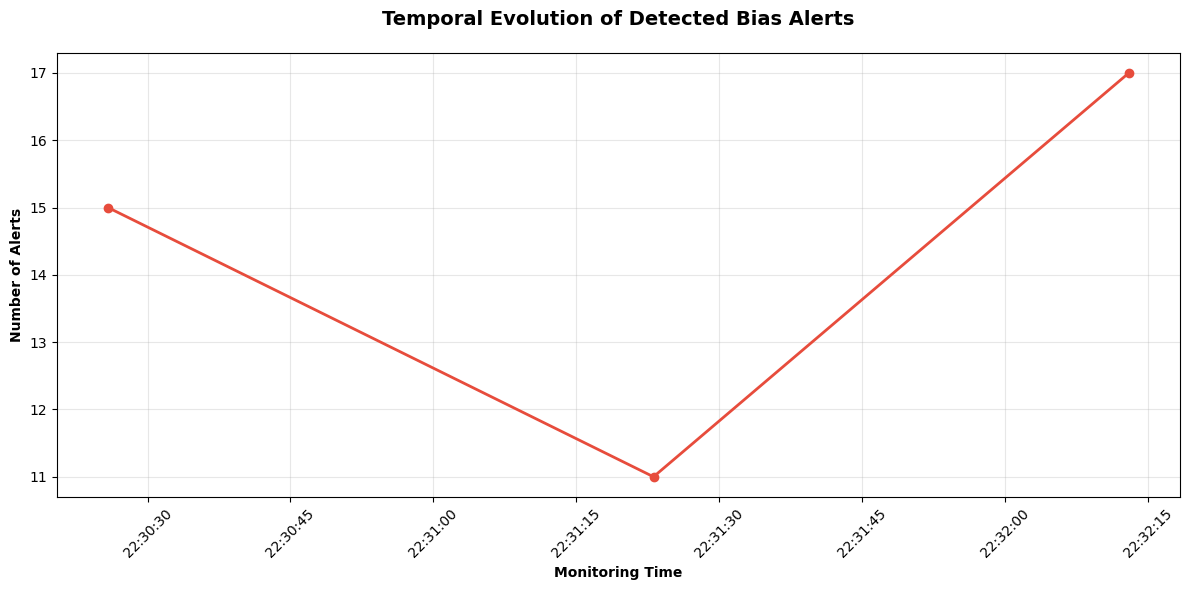

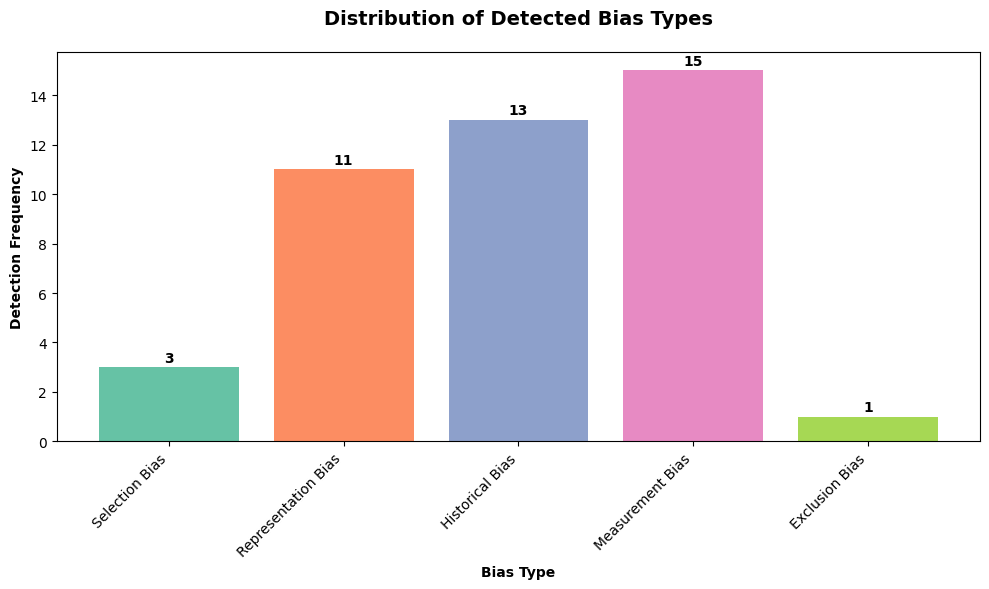

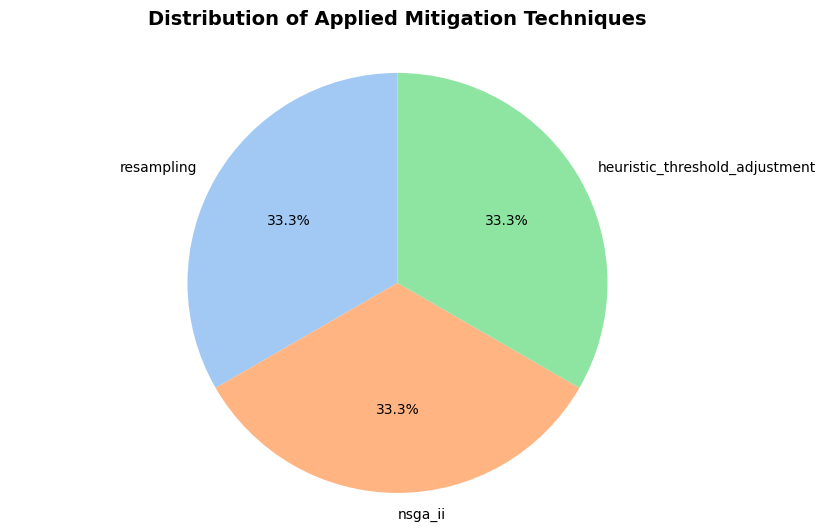

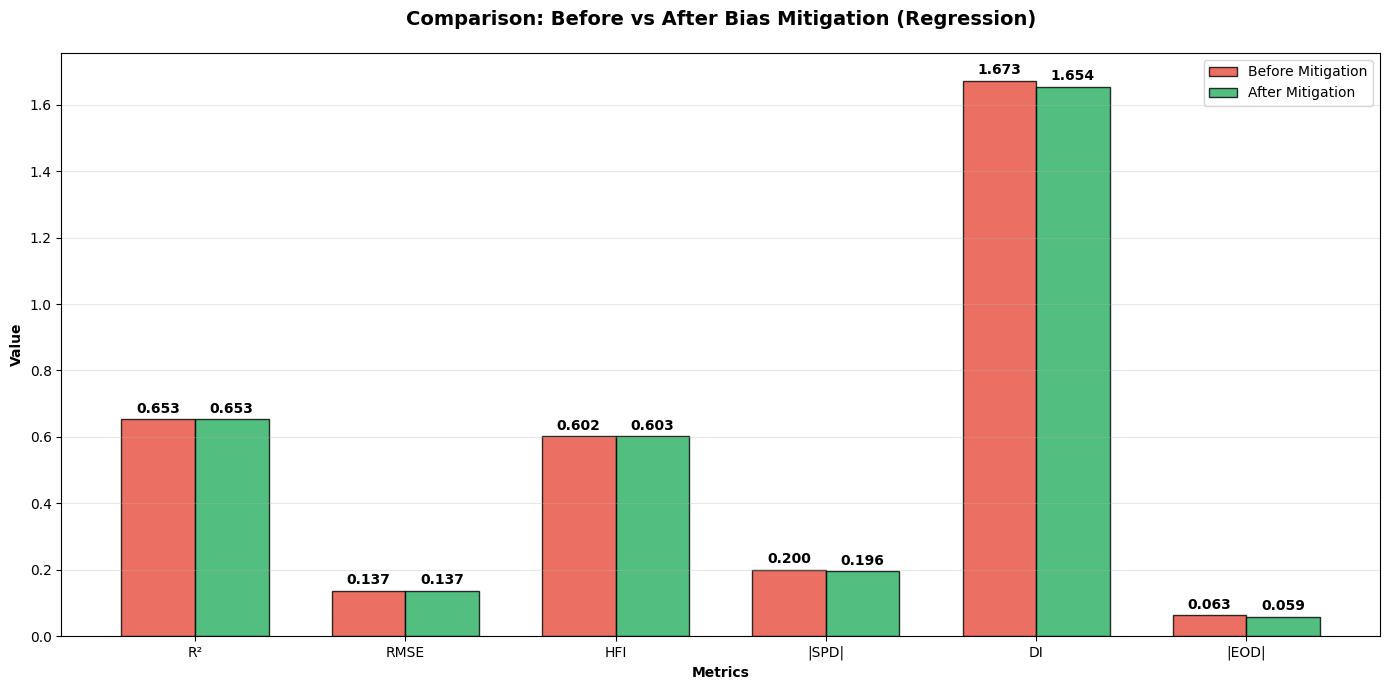


EXECUTION COMPLETED SUCCESSFULLY


In [21]:
def main():
    """
    Main function that executes the complete bias detection and mitigation system.

    Orchestrates the end-to-end flow of the algorithmic fairness system, from
    component initialization to the generation of the final report, with
    specialization for regression problems using the Communities and Crime dataset.

    Process:
        1. Initializes and configures all system components
        2. Verifies data integrity and sensitive columns
        3. Executes real-time monitoring and mitigation cycle
        4. Generates executive report with comparative analysis
    """
    try:
        print("=" * 80)
        print("INTERSECTIONAL BIAS DETECTION AND MITIGATION SYSTEM")
        print("Dataset: Communities and Crime (Regression)")
        print("=" * 80)

        # Initialization of the integrated system for regression
        system = BiasMitigationSystem()

        print("\n" + "=" * 50)
        print("SYSTEM VERIFICATION")
        print("=" * 50)

        # Verification of integrity of required sensitive columns
        if system.df_clean is not None:
            required_cols = ['race_majority_code', 'income_level', 'intersectional_group']
            available_cols = [col for col in required_cols if col in system.df_clean.columns]
            print(f"Sensitive columns available: {available_cols}")

            # Critical validation to ensure intersectional analysis
            if len(available_cols) == len(required_cols):
                print("✓ All sensitive columns are present - System ready for analysis")
            else:
                missing_cols = set(required_cols) - set(available_cols)
                print(f"X Missing critical sensitive columns: {missing_cols}")
                print("The system cannot proceed without the required sensitive columns")
                return

        print("\n" + "=" * 50)
        print("STARTING REAL-TIME MONITORING")
        print("=" * 50)

        # Execution of the complete monitoring and autonomous mitigation cycle
        num_predictions= 600
        alerts, decisions = system.run_complete_monitoring(num_predictions)

        print("\n" + "=" * 50)
        print("EXECUTIVE SUMMARY")
        print("=" * 50)
        print(f"Total alerts detected: {len(alerts)}")
        print(f"Total mitigation decisions: {len(decisions)}")

        # Analysis of system effectiveness
        if decisions:
            successful_mitigations = sum(1 for d in decisions if any(
                exec_result.get('status') == '✓ ACCEPTED'
                for exec_result in d.get('executed', [])
            ))
            print(f"Successful mitigations applied: {successful_mitigations}")

        # Generation of final executive report with visualizations
        system.generate_report(alerts, decisions)

        print("\n" + "=" * 80)
        print("EXECUTION COMPLETED SUCCESSFULLY")
        print("=" * 80)

    except Exception as e:
        print(f"X Critical error in the system's main execution: {e}")
        traceback.print_exc()
        print("\nSuggestion: Verify that the Communities and Crime dataset is available")
        print("and that all system dependencies are correctly installed.")

if __name__ == "__main__":
    main()